# ETTV Surrogate Model — Walkthrough (v5)
**BPS5231 AI for Sustainable Building Design · Interim 1 (Data + EDA) and first surrogate**

> **What the surrogate predicts:** the *actual* ETTV of a design in W/m², whatever it is: 35, 50 or 90.
> Nothing in the data, the training or the predictions is capped, clipped or pushed towards 50 W/m².
> The 50 W/m² limit is only used **afterwards**, to tell the user whether the design complies (§9).

## What is a surrogate model?
A surrogate model (also called a *metamodel* or *emulator*) is a fast ML model trained to imitate a
slower or more cumbersome calculation. You:

1. run the "true" calculation many times on sampled inputs, which gives you a **dataset**
2. train an ML model to map **inputs → output**
3. check it on data it has **never seen**
4. use it where speed matters: design exploration, optimisation, real-time feedback

**Honest framing.** ETTV itself is a cheap formula. This notebook builds the full pipeline on the
formula first, because you can check every step against the exact answer. The research contribution
comes in the final stage, where the "true" calculation becomes a solar simulation of non-standard shading
(SC2), which the BCA tables do not cover well.

## How this notebook is organised
* **Part A (§0–§11):** the full pipeline on one **Latin Hypercube (LHS)** dataset: EDA, features, models,
  evaluation and the compliance check.
* **Part B (§12–§16, new in v3):** the same EDA graphs and validation tests repeated for **all five sampling methods**
  (Random, LHS, Optimised LHS, Sobol, Halton), to verify the sampling plans and validate the surrogates trained on each.

## Pipeline
`Define inputs → Sample (LHS) → Calculate ETTV → EDA → Features → Train/test split → Baseline → Models → Evaluate → Interpret`

> ✅ CF (Table C1) and SC2 (Tables C12–C15) come from the BCA code and are checked against its worked examples in `test_ettv.py`.
> ⚠️ The code's own Appendix D example uses CF values (S 0.58, E 0.77, N 0.57, W 0.87) that **don't match Table C1**
> (0.83, 1.13, 0.80, 1.23). The Appendix D values have been **confirmed as errors**; Table C1 is correct and is used here.
> With Table C1, the Appendix D building scores **61.0 W/m² and fails** the limit (printed: 48.2 W/m²). See §1b (new in v5).

## 0. Setup
On **Colab**, the notebook needs six helper files next to it: `ettv.py`, `sample.py`, `bca_tables.py`, `sampling_methods.py`, `compare_sampling.py` and `bca_examples.py`.
Run the next cell and it will prompt you to upload them (or use the file panel on the left, or `!git clone <your repo>`).
Everything else (numpy, pandas, scipy, scikit-learn, matplotlib) comes preinstalled on Colab, and nothing here needs a GPU.

In [1]:
import os
try:
    from google.colab import files          # only exists on Colab
    missing = [f for f in ("ettv.py", "sample.py", "bca_tables.py", "sampling_methods.py", "compare_sampling.py", "bca_examples.py") if not os.path.exists(f)]
    if missing:
        print("Please upload:", missing)
        files.upload()
except ImportError:
    pass                                     # running locally, nothing to do

In [2]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ettv import ETTV_LIMIT, ORIENTATIONS
from sample import lhs_sample, evaluate_row, PARAM_RANGES

# consistent, colour-blind-checked palette
BLUE, ORANGE, AQUA, YELLOW, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#0b0b0b", "#52514e"
BAND_C = "#f5c77e"   # borderline-band shading
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300,   # v4: saved figures at 300 dpi
                      "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "font.size": 10})
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
SEED = 42

## 1. Define the design space
Each row of the dataset is one **hypothetical building**: a rectangular box with 4 façades.

| Group | Parameters | Why they're included |
|---|---|---|
| Massing | length, width, storeys, floor height, rotation | set façade areas (the area takeoff) and orientations |
| Façade (per face) | WWR 1–4, overhang ratio R1 1–4 (+ one overhang inclination) | the main design levers |
| Materials | U_wall, U_fen, SC1 | envelope specification |

The ranges are **assumptions** anchored to the BCA code's worked examples where possible (see comments in `PARAM_RANGES`).
CF is interpolated between orientations (allowed by the Table C1 note). SC2 uses the nearest orientation's table, so it
**jumps** at ±22.5° boundaries. That's a small discontinuity the surrogate has to learn, and a limitation worth noting in your write-up.

In [3]:
pd.DataFrame(PARAM_RANGES, index=["min", "max"]).T

,min,max
length_m,20.00,80.00
width_m,20.00,60.00
storeys,5.00,40.00
floor_height_m,3.60,4.20
rotation_deg,0.00,360.00
wwr_1,0.20,0.80
wwr_2,0.20,0.80
wwr_3,0.20,0.80
wwr_4,0.20,0.80
r1_1,0.00,1.50


## 1b. Validation against the BCA worked examples (new in v5)
Before trusting any data, the calculator is checked against every worked example in the BCA code.

* **B5.1, B5.2, D1.4:** SC2 look-ups for horizontal overhangs. These should match the code exactly.
* **Appendix D (25-storey office building):** the code prints **48.2 W/m²**, but it uses solar correction factors
  (S 0.58, E 0.77, N 0.57, W 0.87) that **don't match Table C1** (0.83, 1.13, 0.80, 1.23). With the correct Table C1
  values, our calculator gives **61.0 W/m²**, so the building **does not comply**.
* As an arithmetic check, substituting the example's own (wrong) CFs reproduces the printed 48.2 W/m²
  (48.15 before rounding). That shows the only difference is the CFs, not our arithmetic.

`bca_examples.py` holds the example inputs exactly as printed, with two typos corrected (West Ao = 1,785 m², R1 = 1.0).


In [4]:
from bca_examples import validation_table, appendix_d, AUDIT_NOTES
val = pd.DataFrame(validation_table(), columns=["example", "case", "BCA (printed)", "this work"])
display(val)
d = pd.DataFrame({"Table C1 CFs (correct)": appendix_d("table_c1"), "printed CFs (check)": appendix_d("printed")}).T
print("Appendix D building, ETTV by facade (W/m²):")
display(d.round(2))   # 48.15 rounds to the printed 48.2
print("Audit notes on Appendix D:")
for n in AUDIT_NOTES: print(" •", n)


,example,case,BCA (printed),this work
0,B5.1(a),"SC2, SW overhang, R1 = 0.5, φ = 0°",0.6980,0.6981
1,B5.1(b),"SC2, SW overhang, R1 = 0.4, φ = 30°",0.6690,0.6692
2,B5.2,"SC2, W overhang, R1 = 1.5",0.5051,0.5051
3,B5.2,"SC2, W overhang, R1 = 0.32 (interpolated)",0.8123,0.8123
4,D1.4,"SC2, S overhang, R1 = 1.0",0.6800,0.6800
5,D1.4,"SC2, E overhang, R1 = 1.0",0.5800,0.5800
6,App. D,"Building ETTV, Table C1 CFs (correct)",48.2000,61.0000
7,App. D,"Building ETTV, printed CFs (arithmetic check)",48.2000,48.1500


Appendix D building, ETTV by facade (W/m²):


,S,E,N,W,overall
Table C1 CFs (correct),56.23,68.15,50.35,71.34,61.04
printed CFs (check),44.70,52.09,41.60,55.59,48.15


Audit notes on Appendix D:
 • D1.5: CFs printed as S 0.58, E 0.77, N 0.57, W 0.87; Table C1 gives 0.83, 1.13, 0.80, 1.23. With Table C1 the building scores 61.0 W/m2 (fails), not 48.2 W/m2.
 • Summary of envelope area: West Ao printed as 2,356.1 m2; the calculation (and the sum of its parts) is 1,785 m2.
 • D1.4: R1 printed as '0.1'; 3.6/3.6 = 1.0, and the SC2 values used (0.68, 0.58) are the R1 = 1.0 table values.
 • D1.2.2: North wall printed as '3.7 x (20 + 3.6) x 2 = 74.6 m2'; the product is 174.6 m2, as used in the summary.
 • D1.5 East: Aw4 used as 640 m2 (summary: 640.4 m2); South r.c. beam U used as 2.7 (D1.3: 2.71). Negligible.
 • D1.3 U-values recomputed from the listed layers: double glazing 2.95 (printed 2.96), clad r.c. beam 1.97 (printed 1.98). Using recomputed U-values changes the corrected result from 61.04 to 60.99 W/m2.
 • D1.3(c) brick parapet: the layers as listed in the PDF text sum to R = 0.635 m2K/W (U = 1.57), not the printed R = 0.519 (U = 1.93). The printed U 

## 2. Sampling: why Latin Hypercube (LHS)?
*Part A uses LHS. Part B (§12 onwards) compares it with four other methods.*

Purely random sampling leaves clumps and gaps. A full grid explodes in size: 17 parameters × 10 levels is 10¹⁷ runs.
**LHS** splits every parameter's range into *n* equal slices and uses each slice exactly once, so a modest
number of samples still covers every dimension evenly. It is the standard choice for building-simulation surrogates.

In [5]:
N = 10_000
t0 = time.perf_counter()
X_raw = lhs_sample(N, SEED)
Y_raw = pd.DataFrame([evaluate_row(r) for _, r in X_raw.iterrows()])
df = pd.concat([X_raw, Y_raw], axis=1)
calc_time = time.perf_counter() - t0
Path("data").mkdir(exist_ok=True); df.to_csv("data/ettv_dataset.csv", index=False)
print(f"{N:,} buildings calculated in {calc_time:.1f}s")
df.head()

10,000 buildings calculated in 10.4s


,length_m,width_m,storeys,floor_height_m,rotation_deg,wwr_1,wwr_2,wwr_3,wwr_4,r1_1,...,ettv_1,orient_2,sc2_2,ettv_2,orient_3,sc2_3,ettv_3,orient_4,sc2_4,ettv_4
0,44.511356,57.334244,22,3.903978,100.796610,0.703821,0.287734,0.252573,0.631992,0.192232,...,118.600196,S,0.666187,52.956764,W,0.604440,55.330859,N,0.664926,73.148234
1,78.781617,56.556689,7,3.844395,227.723237,0.741922,0.753026,0.354333,0.222788,1.196930,...,35.054411,NW,0.501540,34.989397,NE,0.593849,24.823097,SE,0.509063,18.879958
2,33.119183,39.447242,15,4.082611,92.691831,0.744880,0.566274,0.688410,0.685718,0.342253,...,87.339049,S,0.680750,53.064588,W,0.527528,65.600233,N,0.680420,58.646494
3,44.419956,26.464852,19,3.776598,218.419894,0.786532,0.407566,0.736512,0.691993,0.578900,...,65.662841,NW,0.524594,35.684587,NE,0.558595,52.735732,SE,0.792742,71.479190
4,51.991815,40.326253,5,3.902015,235.409277,0.799686,0.351317,0.602163,0.273002,0.515301,...,72.738794,NW,0.508025,37.663620,NE,0.520036,49.813421,SE,0.466817,32.888517


### Check the sampling covered the space
Each input's histogram should look roughly **flat**; that is what LHS promises.

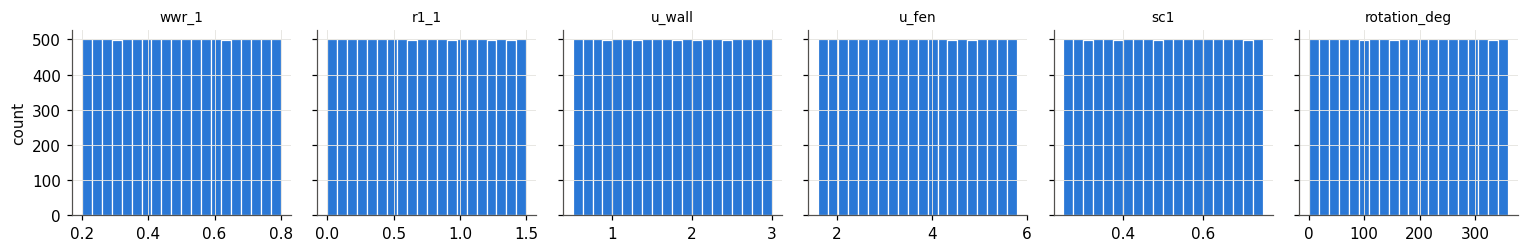

In [6]:
cols = ["wwr_1", "r1_1", "u_wall", "u_fen", "sc1", "rotation_deg"]
fig, axes = plt.subplots(1, len(cols), figsize=(14, 2.4), sharey=True)
for ax, c in zip(axes, cols):
    ax.hist(df[c], bins=20, color=BLUE, edgecolor="white", linewidth=0.8)
    ax.set_title(c, fontsize=9)
axes[0].set_ylabel("count")
plt.tight_layout(); plt.savefig(FIG / "01_input_coverage.png", bbox_inches="tight")

## 3. Exploratory Data Analysis (EDA)
EDA answers: *what does the output look like, what drives it, and is anything odd?*
These are the charts for **Section 4 of your interim report**.

### 3.1 Data quality

In [7]:
print("missing values:", int(df.isna().sum().sum()))
print("duplicate rows:", int(df.duplicated().sum()))
df[["ettv", "q_wall", "q_fen", "q_solar"]].describe().round(2)

missing values: 0
duplicate rows: 0


,ettv,q_wall,q_fen,q_solar
count,10000.00,10000.00,10000.00,10000.00
mean,51.22,10.50,6.29,34.43
std,13.23,4.80,2.38,12.65
min,18.17,1.73,1.41,9.05
25%,41.37,6.54,4.35,24.48
50%,50.12,10.10,6.09,33.01
75%,60.07,14.09,8.00,42.69
max,106.86,25.34,13.62,88.16


### 3.2 Distribution of ETTV and the 50 W/m² limit

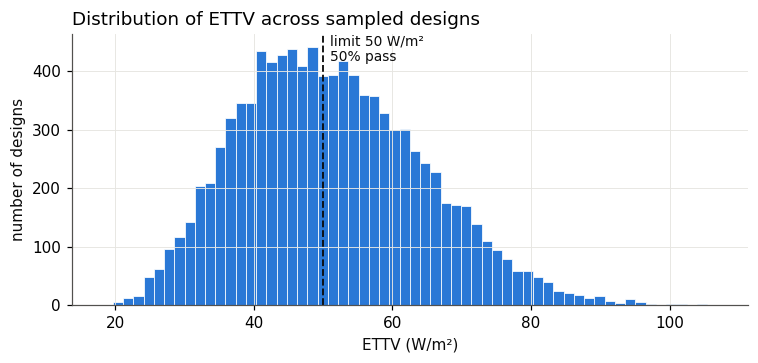

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(df.ettv, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(ETTV_LIMIT, color=INK, linestyle="--", linewidth=1.2)
ax.text(ETTV_LIMIT + 1, ax.get_ylim()[1] * 0.9, f"limit {ETTV_LIMIT:.0f} W/m²\n{df.passes.mean():.0%} pass", color=INK, fontsize=9)
ax.set_xlabel("ETTV (W/m²)"); ax.set_ylabel("number of designs")
ax.set_title("Distribution of ETTV across sampled designs", loc="left")
plt.tight_layout(); plt.savefig(FIG / "02_ettv_distribution.png", bbox_inches="tight")

### 3.3 Which heat-gain component dominates?
ETTV = wall conduction + glass conduction + **solar**. In Singapore's climate you would expect solar gain
through glass to dominate. That is why SC and shading matter so much, and it is the physical case for your SC2 surrogate.

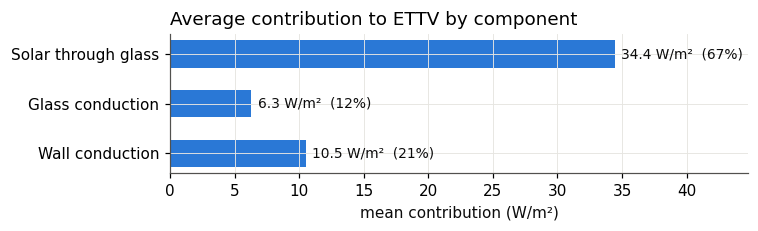

In [9]:
comp = df[["q_wall", "q_fen", "q_solar"]].mean()
share = comp / comp.sum()
fig, ax = plt.subplots(figsize=(7, 2.2))
labels = ["Wall conduction", "Glass conduction", "Solar through glass"]
ax.barh(labels, comp.values, color=BLUE, height=0.55)
for i, (v, s) in enumerate(zip(comp.values, share.values)):
    ax.text(v + 0.5, i, f"{v:.1f} W/m²  ({s:.0%})", va="center", color=INK, fontsize=9)
ax.set_xlim(0, comp.max() * 1.3); ax.set_xlabel("mean contribution (W/m²)")
ax.set_title("Average contribution to ETTV by component", loc="left")
plt.tight_layout(); plt.savefig(FIG / "03_component_share.png", bbox_inches="tight")

### 3.4 Which inputs drive ETTV? (rank correlation)
Spearman correlation measures how consistently ETTV rises or falls with each input. It is a quick first look,
but it only captures one variable at a time and misses interactions.

r1_1             -0.141
r1_3             -0.124
r1_2             -0.116
r1_4             -0.099
overhang_angle   -0.082
length_m         -0.000
rotation_deg      0.004
storeys           0.006
width_m           0.012
floor_height_m    0.025
u_fen             0.146
wwr_2             0.164
wwr_4             0.181
wwr_1             0.187
wwr_3             0.198
u_wall            0.329
sc1               0.763
Name: ettv, dtype: float64

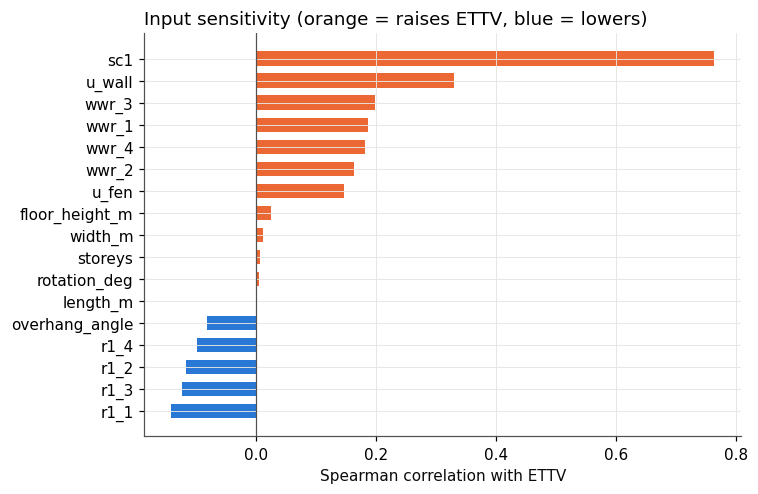

In [10]:
inputs = list(PARAM_RANGES)
corr = df[inputs + ["ettv"]].corr(method="spearman")["ettv"].drop("ettv").sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(corr.index, corr.values, color=[ORANGE if v > 0 else BLUE for v in corr.values], height=0.65)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_xlabel("Spearman correlation with ETTV")
ax.set_title("Input sensitivity (orange = raises ETTV, blue = lowers)", loc="left")
plt.tight_layout(); plt.savefig(FIG / "04_spearman.png", bbox_inches="tight")
corr.round(3)

**What to notice:** `storeys` and `floor_height_m` come out at ≈ 0. Height scales every façade equally, so it cancels
out of the area-weighted average. A good surrogate should learn to ignore those two inputs, and we check that in §7.

### 3.5 Orientation effect
Here we reshape the data so each row is one façade, then compare façade ETTV by orientation.

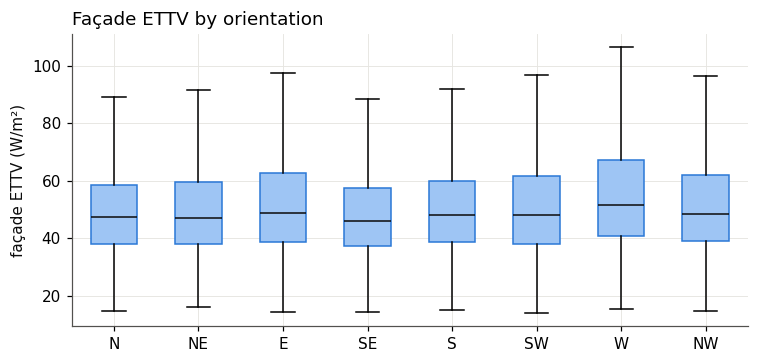

In [11]:
long = pd.concat([pd.DataFrame({"orientation": df[f"orient_{i}"], "ettv_facade": df[f"ettv_{i}"]}) for i in range(1, 5)])
data = [long.loc[long.orientation == o, "ettv_facade"] for o in ORIENTATIONS]
fig, ax = plt.subplots(figsize=(7, 3.4))
bp = ax.boxplot(data, tick_labels=ORIENTATIONS, patch_artist=True, showfliers=False, widths=0.55,
                medianprops=dict(color=INK))
for p in bp["boxes"]: p.set(facecolor="#9ec5f4", edgecolor=BLUE)
ax.set_ylabel("façade ETTV (W/m²)"); ax.set_title("Façade ETTV by orientation", loc="left")
plt.tight_layout(); plt.savefig(FIG / "05_orientation.png", bbox_inches="tight")

### 3.6 Glazing ratio vs ETTV, coloured by glass SC1

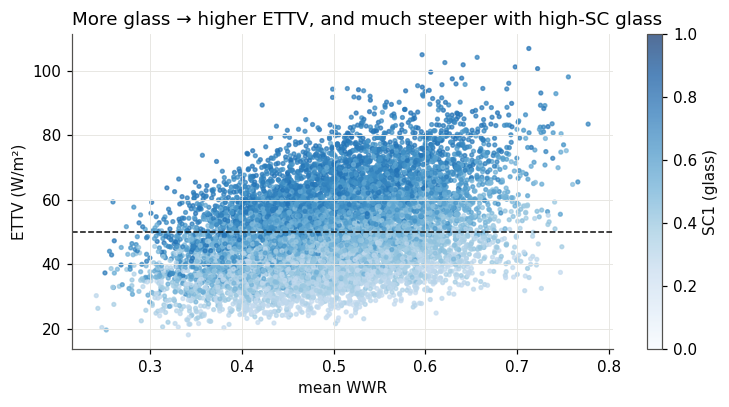

In [12]:
df["wwr_mean"] = df[["wwr_1", "wwr_2", "wwr_3", "wwr_4"]].mean(axis=1)
fig, ax = plt.subplots(figsize=(7, 3.8))
s = ax.scatter(df.wwr_mean, df.ettv, c=df.sc1, cmap="Blues", s=6, alpha=0.7, vmin=0, vmax=1)
ax.axhline(ETTV_LIMIT, color=INK, linestyle="--", linewidth=1)
cb = plt.colorbar(s, ax=ax); cb.set_label("SC1 (glass)")
ax.set_xlabel("mean WWR"); ax.set_ylabel("ETTV (W/m²)")
ax.set_title("More glass → higher ETTV, and much steeper with high-SC glass", loc="left")
plt.tight_layout(); plt.savefig(FIG / "06_wwr_vs_ettv.png", bbox_inches="tight")

**What to notice:** the spread fans out as WWR rises. That is an **interaction** (WWR × SC1): the solar term
is `211·WWR·CF·SC`, a product. Pure linear models struggle with products, which is a hint for the modelling step.

### 3.7 Rotation, a circular variable
0° and 360° are the same direction, but a model sees them as far apart numbers. We will fix that in the next section.

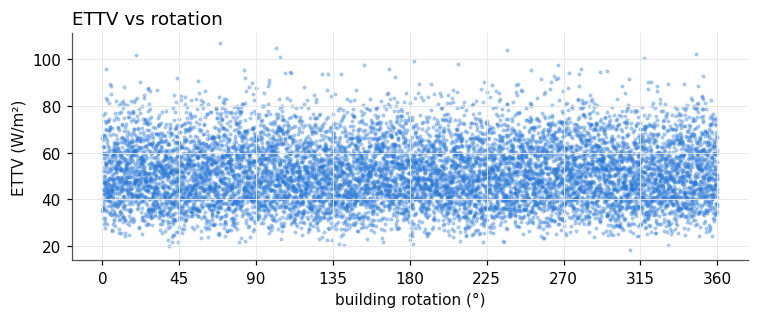

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(df.rotation_deg, df.ettv, s=3, alpha=0.3, color=BLUE)
ax.set_xlabel("building rotation (°)"); ax.set_ylabel("ETTV (W/m²)"); ax.set_xticks(range(0, 361, 45))
ax.set_title("ETTV vs rotation", loc="left")
plt.tight_layout(); plt.savefig(FIG / "07_rotation.png", bbox_inches="tight")

## 4. Feature engineering
**Features** are the columns the model is allowed to see. **Feature engineering** means turning raw inputs into
columns that make the underlying pattern easier to learn, *without* adding information the model shouldn't have.
Here `make_features` does four things.

**1. It starts from the 17 sampled inputs only.** `d[inputs]` selects the design parameters. Everything the calculator
produced (`ettv`, `q_*`, `ettv_1..4`, `sc2_*`, `orient_*`, `passes`) is left out.

**2. Rotation is replaced by `rot_sin` and `rot_cos`.** Rotation is circular: 359° and 1° are 2° apart physically,
but as plain numbers they are 358 apart. A model would have to learn that the two ends of the scale join up, which
wastes data. Mapping the angle onto a circle fixes this:

| rotation | rot_sin | rot_cos |
|---|---|---|
| 0° (face 1 → N) | 0.00 | 1.00 |
| 90° (→ E) | 1.00 | 0.00 |
| 180° (→ S) | 0.00 | −1.00 |
| 270° (→ W) | −1.00 | 0.00 |
| 359° | −0.02 | 1.00 ← right next to 0° |

Two columns are needed because one is ambiguous: sin 30° = sin 150°, but their cosines differ.

**3. `aspect` = length ÷ width is added.** From §3.4, only the *relative* size of the façades matters: the
area-weighted average doesn't care whether a building is 40×20 m or 80×40 m. The ratio gives the model that
information directly, instead of making it discover the relationship between two columns.
`length_m` and `width_m` are kept too, so no information is lost.

**4. Nothing is scaled here.** Scaling (`StandardScaler`) happens later, *inside* the model pipelines in §6, so it
only ever learns from the training rows. Tree models don't need scaling at all.

**⚠️ Data leakage:** feeding the model any column computed *from* the answer would make it look perfect in testing
and useless in practice, because a designer won't have those values. §6.2 tests whether each step actually helps.

In [14]:
def make_features(d):
    F = d[inputs].copy()                         # 1. only the design inputs
    rad = np.deg2rad(F.pop("rotation_deg"))      # 2. degrees -> radians, drop the raw angle
    F["rot_sin"], F["rot_cos"] = np.sin(rad), np.cos(rad)
    F["aspect"] = d.length_m / d.width_m         # 3. relative facade size
    return F                                     # 4. no scaling here

X = make_features(df); y = df.ettv.values
print(X.shape); list(X.columns)

(10000, 19)


['length_m',
 'width_m',
 'storeys',
 'floor_height_m',
 'wwr_1',
 'wwr_2',
 'wwr_3',
 'wwr_4',
 'r1_1',
 'r1_2',
 'r1_3',
 'r1_4',
 'overhang_angle',
 'u_wall',
 'u_fen',
 'sc1',
 'rot_sin',
 'rot_cos',
 'aspect']

## 5. Train / validation / test split
* **Train (70%)**: the model learns from this.
* **Validation (15%)**: used to compare models and tune them.
* **Test (15%)**: locked away and used **once** at the end. This is your honest reported score.

If you tune against the test set, your reported accuracy is optimistic, which is a common mistake.

In [15]:
from sklearn.model_selection import train_test_split
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)
print(len(X_tr), len(X_va), len(X_te))

7000 1500 1500


## 6. Models, from simple to complex
Always start with a **baseline**. If a fancy model can't beat it, you have learnt something useful.

| Model | Idea | Needs scaling? |
|---|---|---|
| Mean predictor | predicts the average ETTV for every design; the "zero skill" line | no |
| Linear regression | weighted sum of the inputs | yes (for interpretation) |
| Random forest | many decision trees, averaged | no |
| Gradient boosting | trees added one at a time, each fixing the previous errors | no |
| Neural net (MLP) | layers of weighted sums with non-linear activations | **yes** |

**Metrics.** MAE is the average error in W/m² and is the easiest to explain. RMSE penalises big misses more.
R² is the share of variance explained, where 1 is perfect. **Pass/fail accuracy** is what a designer actually cares about.

In [16]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Mean (baseline)":   DummyRegressor(),
    "Linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random forest":     RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=SEED),
    "Gradient boosting": HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, random_state=SEED),
    "Neural net (MLP)":  make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1500,
                                        early_stopping=True, random_state=SEED)),
}

def score(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
            "R2": r2_score(y_true, y_pred),
            "pass/fail acc": float(np.mean((y_true <= ETTV_LIMIT) == (y_pred <= ETTV_LIMIT)))}

rows = {}
for name, m in models.items():
    t0 = time.perf_counter(); m.fit(X_tr, y_tr); fit_s = time.perf_counter() - t0
    rows[name] = {**score(y_va, m.predict(X_va)), "train time (s)": fit_s}
results = pd.DataFrame(rows).T
results.round(3)

,MAE,RMSE,R2,pass/fail acc,train time (s)
Mean (baseline),10.595,13.034,-0.001,0.489,0.000
Linear regression,2.731,3.588,0.924,0.928,0.007
Random forest,3.382,4.448,0.883,0.905,10.880
Gradient boosting,1.452,1.988,0.977,0.965,1.232
Neural net (MLP),1.286,1.666,0.984,0.966,3.256


**Reading the table:** every model should clearly beat the mean baseline. Linear regression gets close but
can't capture the WWR × SC products. The MLP and boosting usually come out on top. Pick the best model on
**validation**, then score it **once** on test.

In [17]:
best_name = results["MAE"].idxmin()
best = models[best_name]
test_scores = score(y_te, best.predict(X_te))
print(f"Best on validation: {best_name}")
print("TEST:", {k: round(v, 3) for k, v in test_scores.items()})

Best on validation: Neural net (MLP)
TEST: {'MAE': 1.348, 'RMSE': 1.72, 'R2': 0.982, 'pass/fail acc': 0.972}


### 6.2 Does feature engineering help? (ablation study)
An **ablation** removes one idea at a time and measures the effect. We retrain two models on the *same*
train/validation rows with four feature sets:

* **A. Raw inputs:** the 17 sampled parameters as they are, with rotation in degrees
* **B. A + sin/cos:** rotation replaced by `rot_sin`, `rot_cos`
* **C. B + aspect:** the `make_features` set used in this notebook
* **D. C − height:** also drops `storeys` and `floor_height_m`, which §3.4 showed have no effect

In [18]:
from sklearn.base import clone
def feat_raw(d):     return d[inputs].copy()
def feat_sincos(d):
    F = d[inputs].copy(); rad = np.deg2rad(F.pop("rotation_deg"))
    F["rot_sin"], F["rot_cos"] = np.sin(rad), np.cos(rad); return F
def feat_noheight(d): return make_features(d).drop(columns=["storeys", "floor_height_m"])
feature_sets = {"A. Raw inputs": feat_raw, "B. + sin/cos rotation": feat_sincos,
                "C. + aspect (used here)": make_features, "D. C without height inputs": feat_noheight}
tr_idx, va_idx = X_tr.index, X_va.index
abl = {}
for fs_name, fn in feature_sets.items():
    F = fn(df)
    for m_name in ["Gradient boosting", "Neural net (MLP)"]:
        m = clone(models[m_name]).fit(F.loc[tr_idx], y_tr)
        abl.setdefault(fs_name, {})[m_name] = mean_absolute_error(y_va, m.predict(F.loc[va_idx]))
ablation = pd.DataFrame(abl).T.round(2)
ablation.columns = [c + " MAE" for c in ablation.columns]
ablation

,Gradient boosting MAE,Neural net (MLP) MAE
A. Raw inputs,1.57,1.48
B. + sin/cos rotation,1.50,1.33
C. + aspect (used here),1.45,1.29
D. C without height inputs,1.44,1.14


**Reading the ablation** (numbers from this run; rerunning with other seeds moves them by roughly ±0.1):
* **Each step reduces the error a little**, and the neural net gains most. It went from about 1.5 to about 1.1 W/m²
  between A and D, roughly a quarter less error.
* **Gradient boosting barely changes.** Trees split on one column at a time, so they cope reasonably with raw degrees
  and with useless columns. Neural nets combine all inputs at once, so poorly shaped or irrelevant inputs cost them more.
* **Dropping inputs that don't matter can help.** Just because a column *exists* doesn't mean the model should see it.
  Only drop inputs that you can justify from the physics (§3.4), not just because a score improved.

### 6.1 Parity plots for every model, with the borderline band (v4)
A **parity plot** puts the true BCA ETTV on the x-axis and the surrogate's prediction on the y-axis. A perfect model
puts every point on the black diagonal.

**What the orange elements mean:**
* **Horizontal orange band:** predictions within ±band of 50 W/m². `assess_design` (§9) flags these as
  ⚠️ BORDERLINE instead of giving a pass or fail.
* **Vertical orange band:** designs whose *true* ETTV is within ±band of 50, the genuinely marginal designs.
* **Orange dots:** **pass/fail flipped**. The prediction and the truth fall on opposite sides of 50 W/m², so a plain
  pass/fail answer would be wrong.
  * A flipped dot **inside** the horizontal band is **caught**: the user is told to confirm.
  * A flipped dot **outside** it would be a **silent error**, a confident wrong answer.

**How each band is set:** each model gets its own band, equal to the 95th percentile of its absolute error on the
**validation** set (the calibration data). The **test** set then checks whether that band really covers about 95% of
unseen designs. Calibrating on validation keeps the test set untouched (§5). In v2 and v3 the band was computed on the
test set itself, which is slightly optimistic.

In [19]:
def flips(y_true, y_pred, limit=ETTV_LIMIT):
    return (y_true <= limit) != (y_pred <= limit)

def parity_ax(ax, y_true, y_pred, band, title, limit=ETTV_LIMIT, lim=None, point_size=6):
    lim = lim or [min(y_true.min(), y_pred.min()) - 2, max(y_true.max(), y_pred.max()) + 2]
    ax.axvspan(limit - band, limit + band, color=BAND_C, alpha=0.35, lw=0, zorder=0)
    ax.axhspan(limit - band, limit + band, color=BAND_C, alpha=0.35, lw=0, zorder=0)
    f = flips(y_true, y_pred, limit)
    ax.scatter(y_true[~f], y_pred[~f], s=point_size, alpha=0.5, color=BLUE, lw=0, zorder=2)
    ax.scatter(y_true[f], y_pred[f], s=point_size * 3, color=ORANGE, edgecolor="white", linewidth=0.4, zorder=3,
               label=f"pass/fail flipped ({f.sum()})")
    ax.plot(lim, lim, color=INK, linewidth=1, zorder=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("BCA ETTV (W/m²)"); ax.set_title(title, loc="left", fontsize=10.5)
    ax.legend(loc="upper left", frameon=False, fontsize=8.5, handletextpad=0.2)

def band_report(y_true, y_pred, band, limit=ETTV_LIMIT):
    err = np.abs(y_pred - y_true); f = flips(y_true, y_pred, limit)
    flagged = np.abs(y_pred - limit) <= band
    return {"band ±(W/m²)": band, "MAE": err.mean(), "coverage (|err| ≤ band)": np.mean(err <= band),
            "flipped": int(f.sum()), "flipped & caught": int((f & flagged).sum()),
            "silent flips": int((f & ~flagged).sum()), "share flagged borderline": flagged.mean()}

model_names = list(models)
bands = {n: float(np.percentile(np.abs(models[n].predict(X_va) - y_va), 95)) for n in model_names}
test_preds = {n: models[n].predict(X_te) for n in model_names}
band_tbl = pd.DataFrame({n: band_report(y_te, test_preds[n], bands[n]) for n in model_names}).T
band_tbl.round(3)

,band ±(W/m²),MAE,coverage (|err| ≤ band),flipped,flipped & caught,silent flips,share flagged borderline
Mean (baseline),24.798,10.429,0.953,739.0,739.0,0.0,1.000
Linear regression,7.126,2.861,0.948,103.0,101.0,2.0,0.404
Random forest,9.189,3.442,0.953,133.0,132.0,1.0,0.550
Gradient boosting,4.091,1.507,0.944,43.0,43.0,0.0,0.241
Neural net (MLP),3.345,1.348,0.945,42.0,42.0,0.0,0.189


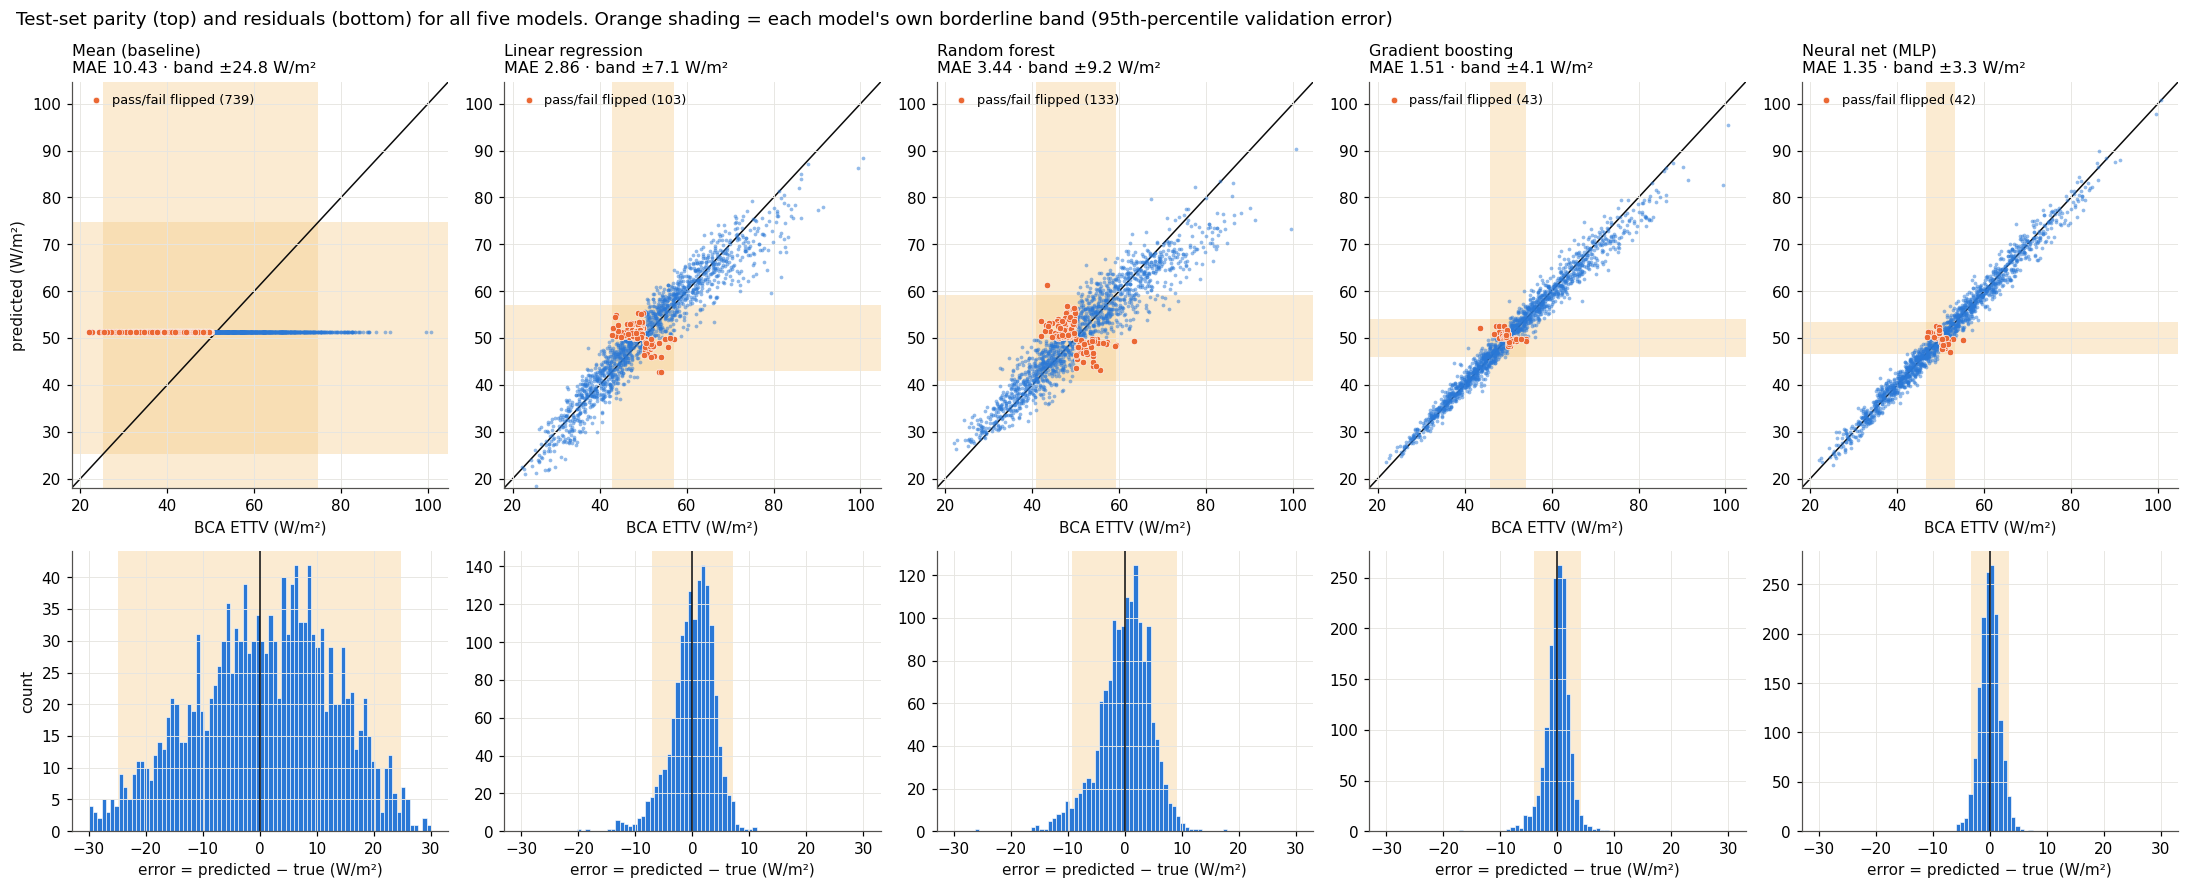

In [20]:
lim = [y_te.min() - 4, y_te.max() + 4]
fig, axes = plt.subplots(2, 5, figsize=(20, 8.2), gridspec_kw={"height_ratios": [1.45, 1]})
for j, n in enumerate(model_names):
    p = test_preds[n]
    parity_ax(axes[0, j], y_te, p, bands[n], f"{n}\nMAE {band_tbl.loc[n, 'MAE']:.2f} · band ±{bands[n]:.1f} W/m²", lim=lim)
    if j == 0: axes[0, j].set_ylabel("predicted (W/m²)")
    ax2 = axes[1, j]
    ax2.axvspan(-bands[n], bands[n], color=BAND_C, alpha=0.35, lw=0)
    ax2.hist(p - y_te, bins=np.linspace(-30, 30, 81), color=BLUE, edgecolor="white", linewidth=0.4)
    ax2.axvline(0, color=INK, linewidth=1); ax2.set_xlabel("error = predicted − true (W/m²)")
    if j == 0: ax2.set_ylabel("count")
plt.suptitle("Test-set parity (top) and residuals (bottom) for all five models. Orange shading = each model's own "
             "borderline band (95th-percentile validation error)", x=0.01, ha="left")
plt.tight_layout(); plt.savefig(FIG / "08b_parity_by_model.png", bbox_inches="tight")

**Reading the plots:**
* **The baseline** predicts the same value for every design. Its band is so wide that nearly everything is
  "borderline", so it is useless as a compliance tool.
* **Linear regression** can't capture the WWR × SC1 products (§3.6), so its errors and band are wide.
* **Random forest** is limited by how finely its trees can split 17 inputs on 7,000 samples.
* **Gradient boosting and the MLP** are the two strong models. The MLP has the **narrowest band**, so it sends the
  fewest designs back for manual checking, and few or no flips slip through silently.

Selecting the MLP rests on three pieces of evidence: the **lowest validation error** (§6, chosen *before* looking at
the test set), the **narrowest borderline band** with **no silent flips** (here), and the **best accuracy once there is
enough data** (§8). Gradient boosting is a close second and a reasonable alternative. Say so in the paper.

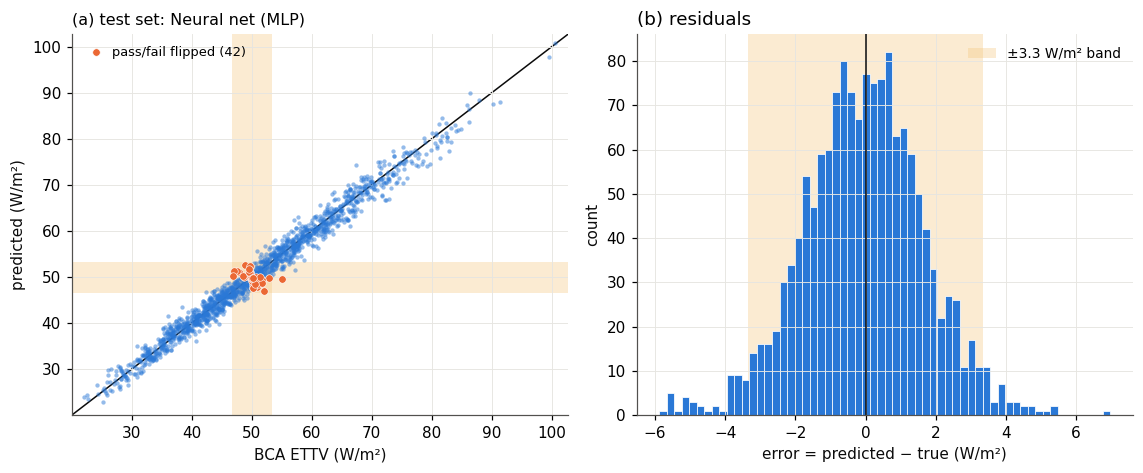

In [21]:
# Conference-style figure for the selected model: parity with band + residuals
p = test_preds[best_name]
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
parity_ax(axes[0], y_te, p, bands[best_name], f"(a) test set: {best_name}", point_size=8)
axes[0].set_ylabel("predicted (W/m²)")
ax = axes[1]
ax.axvspan(-bands[best_name], bands[best_name], color=BAND_C, alpha=0.35, lw=0, label=f"±{bands[best_name]:.1f} W/m² band")
ax.hist(p - y_te, bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=INK, linewidth=1); ax.legend(frameon=False, fontsize=9)
ax.set_xlabel("error = predicted − true (W/m²)"); ax.set_ylabel("count"); ax.set_title("(b) residuals", loc="left")
plt.tight_layout(); plt.savefig(FIG / "08_parity.png", bbox_inches="tight")

## 7. Interpretation: what did the model learn?
**Permutation importance** shuffles one feature and measures how much the error grows. If shuffling a
feature makes no difference, the model doesn't use it. `storeys` and `floor_height_m` should come out near zero,
matching the physics from §3.4, which is a good sign the model learnt something real.

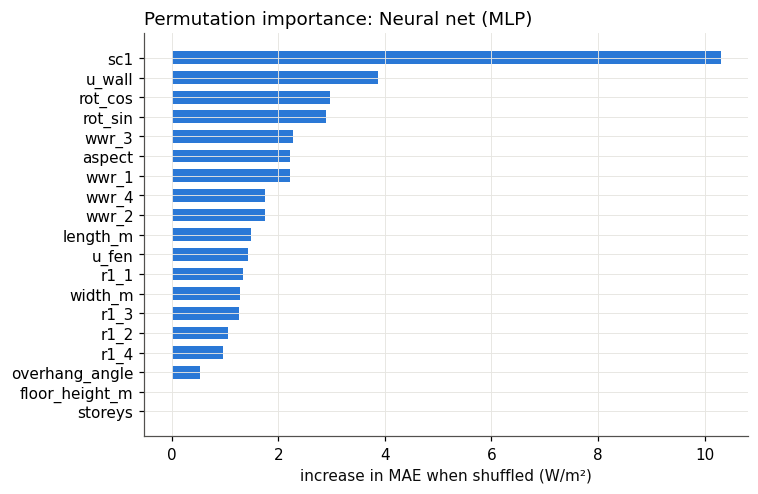

In [22]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(best, X_va, y_va, n_repeats=5, random_state=SEED, scoring="neg_mean_absolute_error")
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(imp.index, imp.values, color=BLUE, height=0.65)
ax.set_xlabel("increase in MAE when shuffled (W/m²)")
ax.set_title(f"Permutation importance: {best_name}", loc="left")
plt.tight_layout(); plt.savefig(FIG / "09_importance.png", bbox_inches="tight")

## 8. How much data do you need? Learning curves for all five models (v4)
This matters for the final project: once the "true" calculation is a slow solar simulation, each sample costs minutes,
not microseconds, and the learning curve tells you roughly how many simulations to budget.

Each model is retrained on random subsets of the training set, from 100 rows up to all 7,000. Each size is repeated
with **3 seeds** (a different subset and, where the model has one, a different random initialisation). Points are the
mean validation score, and bars span the best and worst seed. The right-hand panel shows the score a designer cares
about: how often pass/fail is right.

model,Mean (baseline),Linear regression,Random forest,Gradient boosting,Neural net (MLP)
n,,,,,
100,10.68,3.26,5.62,4.36,5.52
250,10.70,2.87,5.09,3.70,4.77
500,10.56,2.77,4.50,3.16,3.79
1000,10.61,2.77,4.21,2.85,2.86
2500,10.61,2.75,3.78,2.10,1.98
5000,10.59,2.73,3.48,1.64,1.52
7000,10.60,2.73,3.37,1.45,1.37


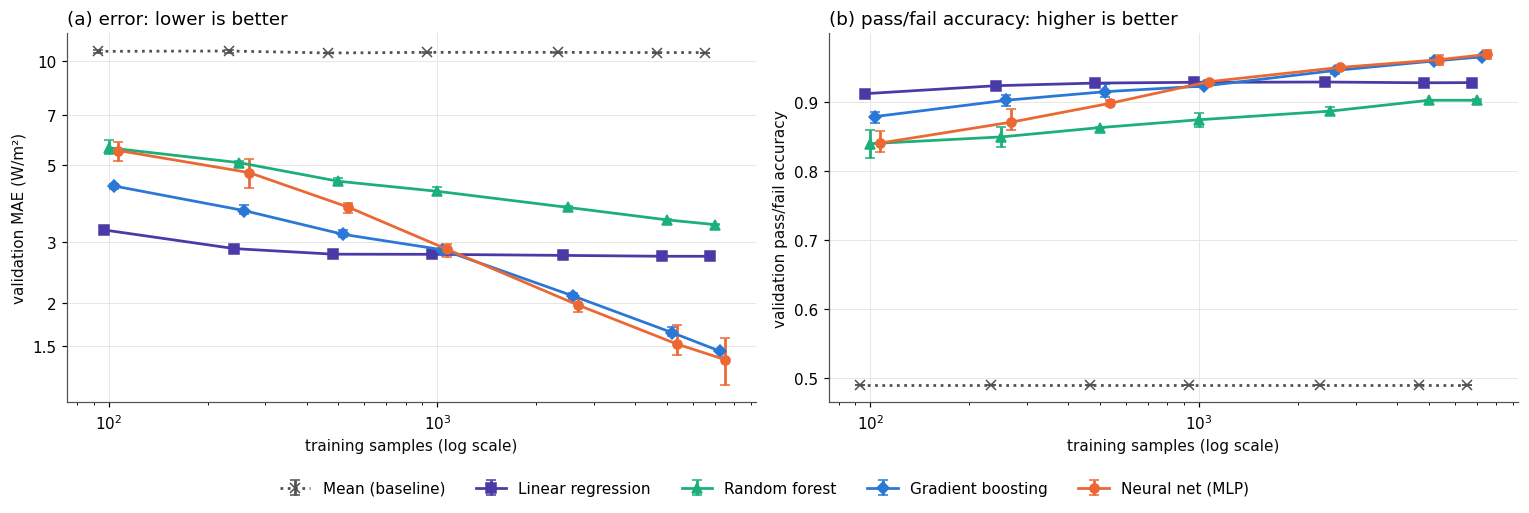

In [23]:
from sklearn.base import clone
sizes = [100, 250, 500, 1000, 2500, 5000, len(X_tr)]
MODEL_STYLE = {"Mean (baseline)": (MUTED, "x", ":"), "Linear regression": ("#4a3aa7", "s", "-"),
               "Random forest": (AQUA, "^", "-"), "Gradient boosting": (BLUE, "D", "-"), "Neural net (MLP)": (ORANGE, "o", "-")}
rows = []
for n in sizes:
    for r in range(3):
        idx = np.random.default_rng(r).choice(len(X_tr), size=n, replace=False)
        for name in model_names:
            m = clone(models[name])
            rs_keys = [k for k in m.get_params() if k.endswith("random_state")]
            if rs_keys: m.set_params(**{k: r for k in rs_keys})
            m.fit(X_tr.iloc[idx], y_tr[idx]); pv = m.predict(X_va)
            rows.append(dict(n=n, model=name, seed=r, mae=mean_absolute_error(y_va, pv),
                             passfail=float(np.mean((pv <= ETTV_LIMIT) == (y_va <= ETTV_LIMIT)))))
lc = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, metric, lab in [(axes[0], "mae", "validation MAE (W/m²)"), (axes[1], "passfail", "validation pass/fail accuracy")]:
    for k, name in enumerate(model_names):
        col, mk, ls = MODEL_STYLE[name]
        g = lc[lc.model == name].groupby("n")[metric]
        x = np.array(g.mean().index) * (1 + 0.035 * (k - 2))
        ax.errorbar(x, g.mean(), yerr=np.clip([g.mean() - g.min(), g.max() - g.mean()], 0, None), color=col, marker=mk, ls=ls,
                    markersize=6, linewidth=1.8, capsize=3, label=name)
    ax.set_xscale("log"); ax.set_xlabel("training samples (log scale)"); ax.set_ylabel(lab)
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
axes[0].set_yscale("log"); axes[0].yaxis.set_major_locator(FixedLocator([1, 1.5, 2, 3, 5, 7, 10]))
axes[0].yaxis.set_major_formatter(FixedFormatter(["1", "1.5", "2", "3", "5", "7", "10"])); axes[0].yaxis.set_minor_locator(NullLocator())
axes[0].set_title("(a) error: lower is better", loc="left")
axes[1].set_title("(b) pass/fail accuracy: higher is better", loc="left")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.savefig(FIG / "10_learning_curve.png", bbox_inches="tight")
lc.groupby(["n", "model"]).mae.mean().unstack("model")[model_names].round(2)

**What the learning curves show** (numbers from this run):
* **With little data, simple wins.** Below about 1,000 samples, **linear regression** has the lowest error (about
  2.8 W/m²) and the best pass/fail accuracy. The flexible models (GB, MLP, RF) don't yet have enough examples to learn
  the WWR × SC1 products.
* **With more data, flexible models take over.** Gradient boosting overtakes linear regression at about 1,000 samples,
  and the MLP overtakes gradient boosting at about 2,500. With all 7,000 samples the MLP is best: 1.37 W/m², against
  1.45 for gradient boosting and 2.73 for linear regression.
* **Linear regression plateaus at about 2.7 W/m².** More data can't fix a model that can't represent the physics,
  whereas the MLP and gradient boosting are still improving at 7,000. More data would help them further.
* **Random forest stays behind gradient boosting** at every size, and the **baseline** is flat at about 10.6 W/m².
* **Be honest about the MLP vs gradient boosting gap.** At 7,000 samples the MLP is ahead on average, but its seed-to-seed
  bar overlaps gradient boosting's, so on error alone the two are close. The clearer differences are the MLP's
  narrower borderline band (±3.3 vs ±4.1 W/m²), and the smaller share of designs it flags for manual checking (19% vs 24%), in §6.1.

**What this means for your write-up:** the MLP is the right choice *for this data budget* (thousands of cheap samples).
The selection depends on how much data you can afford. In the final project, if each sample is a slow simulation and
you can only run a few hundred, rerun this comparison: linear regression or gradient boosting may then be the better
surrogate.

## 9. Using the surrogate: predict ETTV and flag compliance
This is how a designer would use the model. `assess_design` takes one design, predicts its ETTV, and reports it
against the 50 W/m² limit. The prediction is the model's honest estimate and is **never adjusted towards 50**.

The surrogate has a small error, so a prediction just under 50 could really be just over it. The function therefore
uses a **borderline band**: the selected model's 95th-percentile absolute error on the **validation** set (§6.1).
In other words, 95% of validation predictions were within this distance of the true value.

| Predicted ETTV | Status |
|---|---|
| below 50 − band | ✅ COMPLIES |
| within ±band of 50 | ⚠️ BORDERLINE: confirm with the exact BCA calculation |
| above 50 + band | ❌ EXCEEDS, with the amount it is over by |

The predicted value is always reported as it is, so a design at 95 W/m² is shown as 95, not as "fail" alone.

In [24]:
band = bands[best_name]                         # calibrated on validation in §6.1
cov = np.mean(np.abs(best.predict(X_te) - y_te) <= band)
print(f"Borderline band = ±{band:.2f} W/m² (95th percentile of validation errors); "
      f"it covers {cov:.1%} of the unseen test set")

def assess_design(design: dict, model=best, limit=ETTV_LIMIT, band=band, show_exact=True):
    row = pd.DataFrame([design])
    pred = float(model.predict(make_features(row))[0])          # raw prediction, no clipping
    outside = [k for k, (lo, hi) in PARAM_RANGES.items() if not lo <= design[k] <= hi]
    if pred > limit + band:
        status = f"❌ EXCEEDS the {limit:.0f} W/m² limit by {pred - limit:.1f} W/m²"
    elif pred < limit - band:
        status = f"✅ COMPLIES ({limit - pred:.1f} W/m² below the {limit:.0f} W/m² limit)"
    else:
        status = f"⚠️ BORDERLINE (within ±{band:.1f} W/m² of the limit): confirm with the exact BCA calculation"
    if outside:
        status += f" | ⚠️ inputs outside training range: {outside}, so treat the prediction as unreliable"
    elif not y_tr.min() <= pred <= y_tr.max():
        status += " | ⚠️ beyond the ETTV range seen in training, so accuracy is lower"
    out = {"predicted_ettv": round(pred, 1), "status": status}
    if show_exact:                                              # only possible because our ground truth is cheap
        out["exact_ettv (BCA calc)"] = round(evaluate_row(pd.Series(design))["ettv"], 1)
    return out

base = dict(length_m=50, width_m=30, storeys=20, floor_height_m=3.8, rotation_deg=0,
            r1_1=0.5, r1_2=0.5, r1_3=0.5, r1_4=0.5, overhang_angle=0)
examples = {
    "Low-e glass, 40% WWR, insulated wall": dict(base, wwr_1=0.4, wwr_2=0.4, wwr_3=0.4, wwr_4=0.4, u_wall=0.6, u_fen=1.8, sc1=0.3),
    "Clear glass, 70% WWR, no overhangs": dict(base, wwr_1=0.7, wwr_2=0.7, wwr_3=0.7, wwr_4=0.7, u_wall=2.0, u_fen=5.8, sc1=0.7,
                                               r1_1=0, r1_2=0, r1_3=0, r1_4=0),
    "Mid-spec design": dict(base, wwr_1=0.5, wwr_2=0.5, wwr_3=0.5, wwr_4=0.5, u_wall=1.5, u_fen=2.8, sc1=0.45),
    "Mid-spec, slightly clearer glass": dict(base, wwr_1=0.5, wwr_2=0.5, wwr_3=0.5, wwr_4=0.5, u_wall=1.5, u_fen=2.8, sc1=0.50),
}
pd.set_option("display.max_colwidth", None)   # show the full status text
pd.DataFrame({k: assess_design(v) for k, v in examples.items()}).T

Borderline band = ±3.35 W/m² (95th percentile of validation errors); it covers 94.5% of the unseen test set


,predicted_ettv,status,exact_ettv (BCA calc)
"Low-e glass, 40% WWR, insulated wall",24.5,✅ COMPLIES (25.5 W/m² below the 50 W/m² limit),24.2
"Clear glass, 70% WWR, no overhangs",114.7,"❌ EXCEEDS the 50 W/m² limit by 64.7 W/m² | ⚠️ beyond the ETTV range seen in training, so accuracy is lower",119.4
Mid-spec design,45.5,✅ COMPLIES (4.5 W/m² below the 50 W/m² limit),46.4
"Mid-spec, slightly clearer glass",49.1,⚠️ BORDERLINE (within ±3.3 W/m² of the limit): confirm with the exact BCA calculation,50.1


**Why the borderline band matters:** in the fourth example the surrogate predicts about 49 W/m², which on its own looks like
a pass. The exact calculation gives about 50.1 W/m², which is a fail. Because 49 is within the band, the function says
*borderline, confirm* instead of giving a false pass.

**Two extra warnings are built in.** A surrogate is only reliable *inside* the region it was trained on:
* if any input is outside `PARAM_RANGES`, the prediction is flagged as unreliable (extrapolation)
* if the prediction is beyond the highest or lowest ETTV seen in training, it's flagged as less accurate.
  The clear-glass example shows why: every input is in range, but all four façades at 70% glass with no shading
  is an extreme corner of the design space, and the error there is larger than average.

The **exact** column is shown only to check the surrogate. It's available because our ground truth is a fast formula.
Once the ground truth is a slow SC2 simulation, the prediction and its status are what a designer would see.

### Why this band width? (v4)
The band answers one question: *how close to 50 W/m² must a prediction be before we stop trusting a plain pass/fail?*

* **It comes from the model's own errors.** The value isn't picked by hand. It is the distance within which 95% of the
  model's validation predictions fell, so a design predicted outside the band is very unlikely (about 1 in 20 or less)
  to be on the other side of the limit.
* **95% is a convention, not a rule.** It's the usual coverage level for engineering uncertainty statements, and the
  trade-off is simple. A **wider band** (99th percentile) catches more borderline cases but sends more designs back for
  checking. A **narrower band** (90th) flags fewer designs but lets more silent flips through. The table below shows
  how this plays out on the test set.
* **It's a property of the model, not of ETTV.** A better model has smaller errors, so its band is narrower. That's why
  the band changes between models (§6.1), and why it would change if the data changed.
* **In v2 and v3 the band was ±3.4 W/m²,** because it was computed from the *test* errors. v4 calibrates it on the
  validation set instead, so the value can differ slightly. The coverage figure printed above checks it on unseen data.

In [25]:
err_va = np.abs(best.predict(X_va) - y_va); p_te = best.predict(X_te)
alt = {}
for q in (80, 90, 95, 99):
    b = float(np.percentile(err_va, q))
    alt[f"{q}th percentile"] = band_report(y_te, p_te, b)
alt["2 × RMSE (validation)"] = band_report(y_te, p_te, float(2 * np.sqrt(np.mean(err_va ** 2))))
pd.DataFrame(alt).T[["band ±(W/m²)", "coverage (|err| ≤ band)", "flipped", "silent flips", "share flagged borderline"]].round(3)

,band ±(W/m²),coverage (|err| ≤ band),flipped,silent flips,share flagged borderline
80th percentile,2.007,0.779,42.0,7.0,0.108
90th percentile,2.750,0.895,42.0,1.0,0.149
95th percentile,3.345,0.945,42.0,0.0,0.189
99th percentile,4.697,0.986,42.0,0.0,0.276
2 × RMSE (validation),3.331,0.945,42.0,0.0,0.189


## 10. Speed check

In [26]:
t0 = time.perf_counter(); best.predict(X_te); surr_s = time.perf_counter() - t0
print(f"Calculator: {calc_time / N * 1e3:.3f} ms per design (Python loop)")
print(f"Surrogate : {surr_s / len(X_te) * 1e3:.4f} ms per design (batched)")

Calculator: 1.035 ms per design (Python loop)
Surrogate : 0.0013 ms per design (batched)


**Be honest in the write-up:** for the pure formula, both are practically instant. The surrogate's value appears
when the ground truth is slow, e.g. a Radiance or EnergyPlus run for complex shading that takes seconds to minutes.

## 11. Next steps toward the final submission
1. Report the Appendix D result as **61.0 W/m²** (Table C1 CFs), and mention the CF error in the code's example (§1b).
2. **Hyperparameter tuning** on the best model with `GridSearchCV` or Optuna, using cross-validation on train only.
3. **SC2 surrogate:** parameterise a non-standard shading device (fin depth and angle, louvre spacing, and so on),
   simulate its solar reduction with Ladybug Tools or EnergyPlus, and train a surrogate on those results.
4. Feed the SC2 surrogate into the ETTV calculator, which gives you a *hybrid physics + ML* model.
5. **Optimisation demo:** search the surrogate for façades whose *predicted* ETTV is below 50 W/m², then confirm the best ones with the exact calculation.

---
# Part B: Comparing the five sampling methods (verification & validation)

Part A used one sampling method (LHS). Part B asks whether the choice of method changes the data or the surrogate.
Every method feeds **the same BCA calculator with the same input ranges**. Only *where* the samples sit differs.

| Method | How it places points |
|---|---|
| **Random** | independent uniform draws, the Monte Carlo baseline |
| **LHS** | each input's range cut into *n* equal slices, exactly one sample per slice |
| **Optimised LHS** | LHS, then rearranged to minimise discrepancy so input *pairs* are also evenly covered |
| **Sobol** | scrambled low-discrepancy sequence; best when *n* is a power of 2 |
| **Halton** | scrambled low-discrepancy sequence built from prime bases |

**Two kinds of checks:**
* **Verification** (§13–§14): is each sampling plan doing its job, and does it produce consistent data?
  Space-filling metrics, then the same EDA graphs as §3 repeated for every method.
* **Validation** (§15): does a surrogate trained on each method's data predict **unseen** designs accurately?
  Every model is tested on one common, independent test set.

To keep the comparison fair, every method uses **n = 8,192 = 2¹³** samples (a power of 2, which Sobol needs).
Part B takes about 5 minutes to run.

## 12. Generate one dataset per method

In [27]:
import warnings
from scipy import stats
from sampling_methods import METHODS, generate_dataset, unit_sample, space_filling_metrics
warnings.filterwarnings("ignore", message=".*balance properties.*")   # Sobol power-of-2 notice

N_CMP = 8192
M_COL = dict(zip(METHODS, [BLUE, ORANGE, AQUA, YELLOW, "#e87ba4"]))     # colour-blind-checked
M_MRK = dict(zip(METHODS, ["o", "s", "^", "D", "v"]))                    # second cue besides colour
datasets, unit_pts, gen_time = {}, {}, {}
for m in METHODS:
    t0 = time.perf_counter()
    datasets[m], unit_pts[m] = generate_dataset(m, N_CMP, SEED)
    gen_time[m] = time.perf_counter() - t0
    datasets[m].to_csv(f"data/ettv_dataset_{m.lower().replace(' ', '_')}.csv", index=False)

summary = pd.DataFrame({m: {"rows": len(d), "generation time (s)": gen_time[m],
                            "ETTV mean": d.ettv.mean(), "ETTV std": d.ettv.std(),
                            "ETTV min": d.ettv.min(), "ETTV max": d.ettv.max(),
                            "share passing 50 W/m²": d.passes.mean(),
                            "KS statistic vs LHS": stats.ks_2samp(d.ettv, datasets["LHS"].ettv).statistic}
                        for m, d in datasets.items()}).T
summary.round(3)

,rows,generation time (s),ETTV mean,ETTV std,ETTV min,ETTV max,share passing 50 W/m²,KS statistic vs LHS
Random,8192.0,8.875,51.176,13.224,18.828,102.616,0.501,0.011
LHS,8192.0,8.630,51.130,13.161,19.349,108.068,0.502,0.000
Optimised LHS,8192.0,35.317,51.177,13.248,17.931,111.773,0.502,0.004
Sobol,8192.0,8.690,51.205,13.276,17.012,106.490,0.501,0.009
Halton,8192.0,8.517,51.218,13.304,17.052,104.662,0.504,0.009


**Reading the table:** all five datasets describe the same design space, so their ETTV statistics should be almost
identical. The **KS statistic** measures the largest gap between two distributions (0 means identical); values
around 0.01–0.02 mean the methods agree. Generation time is mostly the BCA calculation, except Optimised LHS, which
spends extra time rearranging its points.

## 13. Verification 1: how evenly does each method fill the design space?
These metrics look only at the sample points, before any ETTV is calculated.

* **Centred L2 discrepancy:** how far the points are from perfectly uniform. **Lower is better.**
* **Empty slices per input:** cut each input's range into *n* equal slices and count the share that hold no sample.
  LHS guarantees 0.
* **Nearest-neighbour (NN) distance:** the distance from each point to its closest neighbour, on a 2,000-point subset.
  A **higher minimum** means fewer clumps.

In [28]:
sf = pd.DataFrame({m: space_filling_metrics(unit_pts[m]) for m in METHODS}).T
sf.round(4)

,centred L2 discrepancy,empty slices per input,min NN distance,mean NN distance
Random,0.0047,0.3677,0.4426,0.8501
LHS,0.0037,0.0000,0.5743,0.8503
Optimised LHS,0.0024,0.0000,0.4127,0.8523
Sobol,0.0015,0.0000,0.5422,0.8636
Halton,0.0016,0.2351,0.5315,0.8534


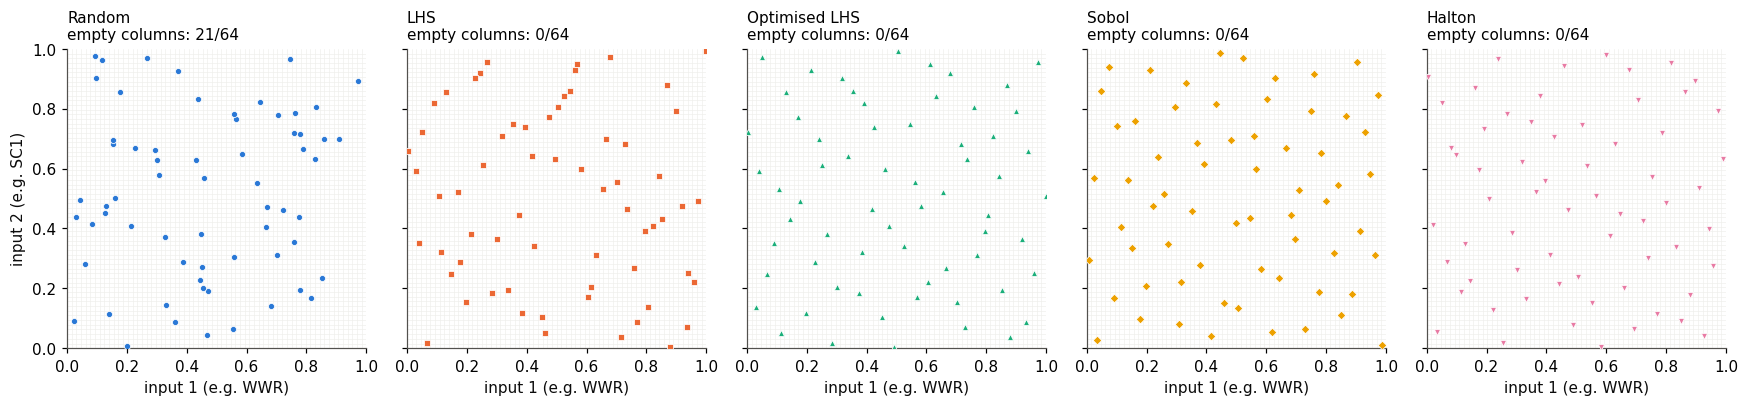

In [29]:
# The same idea in 2-D: 64 points of two inputs, with the range cut into 64 slices each way
n_demo = 64
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6), sharey=True)
for ax, m in zip(axes, METHODS):
    U = unit_sample(m, n_demo, SEED, d=2)
    for k in range(1, n_demo):
        ax.axvline(k / n_demo, color="#eeeeea", lw=0.4); ax.axhline(k / n_demo, color="#eeeeea", lw=0.4)
    ax.scatter(U[:, 0], U[:, 1], s=16, color=M_COL[m], marker=M_MRK[m], edgecolor="white", linewidth=0.5, zorder=3)
    ec = n_demo - len(set((U[:, 0] * n_demo).astype(int)))
    ax.set_title(f"{m}\nempty columns: {ec}/{n_demo}", loc="left", fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal"); ax.grid(False)
    ax.set_xlabel("input 1 (e.g. WWR)")
axes[0].set_ylabel("input 2 (e.g. SC1)")
plt.tight_layout(); plt.savefig(FIG / "12_sampling_2d_projection.png", bbox_inches="tight")

## 14. Verification 2: the §3 EDA graphs, repeated for every method
If a sampling method is sound, its dataset should tell the **same physical story** as the LHS data in §3:
the same distributions, the same drivers and the same trends. Any big difference would point to a sampling problem.

### 14.1 Input coverage (as §2)
Each histogram should be roughly **flat**. Watch how bumpy Random is compared with the others.

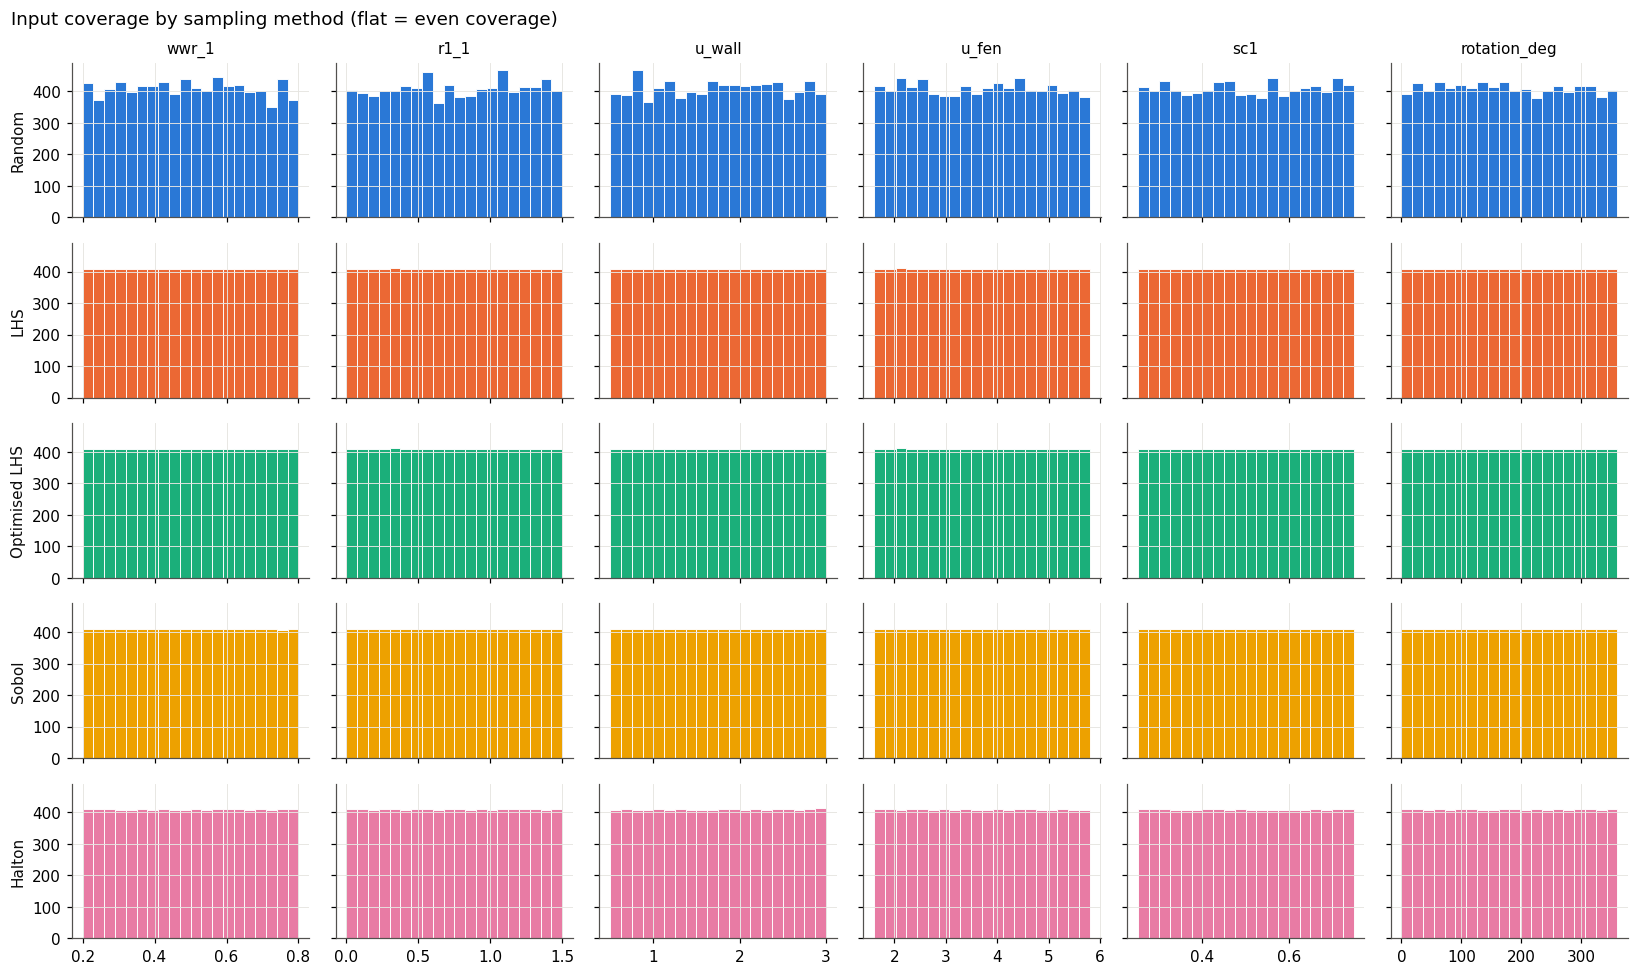

In [30]:
cols = ["wwr_1", "r1_1", "u_wall", "u_fen", "sc1", "rotation_deg"]
fig, axes = plt.subplots(len(METHODS), len(cols), figsize=(15, 9), sharex="col", sharey=True)
for i, m in enumerate(METHODS):
    for j, c in enumerate(cols):
        ax = axes[i, j]
        ax.hist(datasets[m][c], bins=20, color=M_COL[m], edgecolor="white", linewidth=0.6)
        if i == 0: ax.set_title(c, fontsize=10)
        if j == 0: ax.set_ylabel(m, fontsize=10)
plt.suptitle("Input coverage by sampling method (flat = even coverage)", x=0.01, ha="left", fontsize=12)
plt.tight_layout(); plt.savefig(FIG / "13_input_coverage_by_method.png", bbox_inches="tight")

### 14.2 ETTV distribution and the 50 W/m² limit (as §3.2)

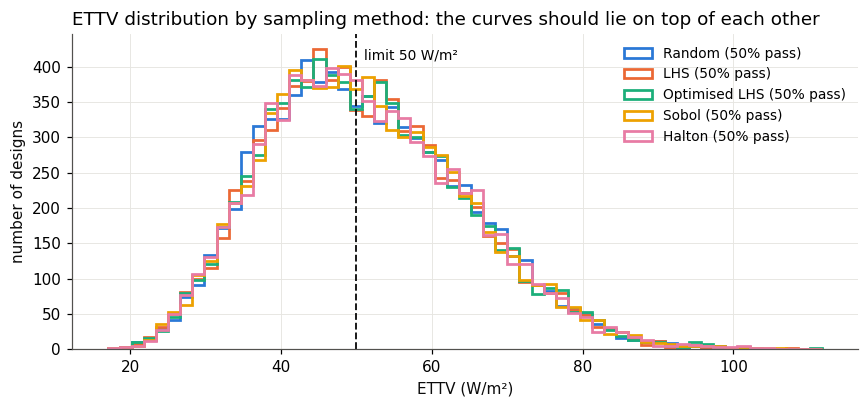

In [31]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.linspace(min(d.ettv.min() for d in datasets.values()), max(d.ettv.max() for d in datasets.values()), 60)
for m in METHODS:
    ax.hist(datasets[m].ettv, bins=bins, histtype="step", linewidth=1.8, color=M_COL[m],
            label=f"{m} ({datasets[m].passes.mean():.0%} pass)")
ax.axvline(ETTV_LIMIT, color=INK, linestyle="--", linewidth=1.2)
ax.text(ETTV_LIMIT + 1, ax.get_ylim()[1] * 0.92, f"limit {ETTV_LIMIT:.0f} W/m²", fontsize=9)
ax.set_xlabel("ETTV (W/m²)"); ax.set_ylabel("number of designs"); ax.legend(frameon=False, fontsize=9)
ax.set_title("ETTV distribution by sampling method: the curves should lie on top of each other", loc="left")
plt.tight_layout(); plt.savefig(FIG / "14_ettv_distribution_by_method.png", bbox_inches="tight")

### 14.3 Which heat-gain component dominates? (as §3.3)

,Wall conduction (%),Glass conduction (%),Solar through glass (%)
Random,20.6,12.2,67.1
LHS,20.5,12.3,67.1
Optimised LHS,20.5,12.3,67.2
Sobol,20.5,12.3,67.2
Halton,20.5,12.3,67.2


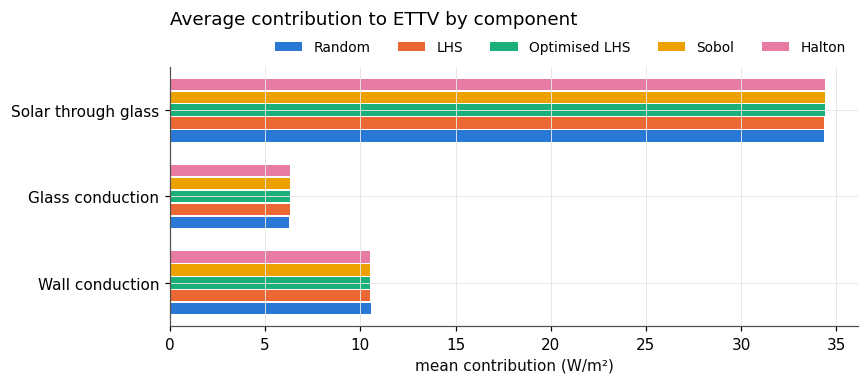

In [32]:
comp_m = pd.DataFrame({m: d[["q_wall", "q_fen", "q_solar"]].mean() for m, d in datasets.items()}).T
comp_m.columns = ["Wall conduction", "Glass conduction", "Solar through glass"]
fig, ax = plt.subplots(figsize=(8, 3.6))
yb = np.arange(3); h = 0.15
for i, m in enumerate(METHODS):
    ax.barh(yb + (i - 2) * h, comp_m.loc[m].values, height=h * 0.9, color=M_COL[m], label=m)
ax.set_yticks(yb); ax.set_yticklabels(comp_m.columns); ax.set_xlabel("mean contribution (W/m²)")
ax.legend(frameon=False, fontsize=9, ncol=5, loc="lower right", bbox_to_anchor=(1, 1.0))
ax.set_title("Average contribution to ETTV by component", loc="left", pad=28)
plt.tight_layout(); plt.savefig(FIG / "15_component_share_by_method.png", bbox_inches="tight")
(comp_m.div(comp_m.sum(axis=1), axis=0) * 100).round(1).add_suffix(" (%)")

### 14.4 Which inputs drive ETTV? (as §3.4)

largest difference from LHS across all inputs: 0.024


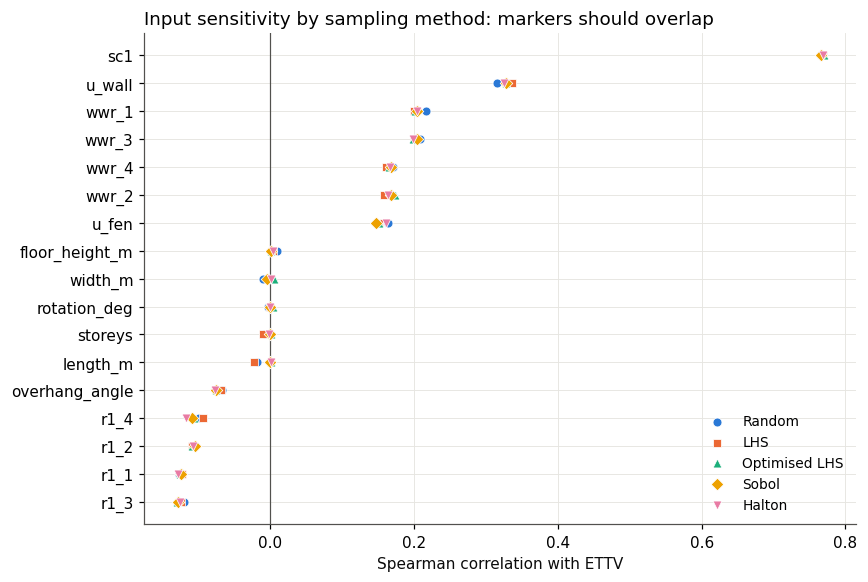

In [33]:
sp = pd.DataFrame({m: d[inputs + ["ettv"]].corr(method="spearman")["ettv"].drop("ettv") for m, d in datasets.items()})
sp = sp.loc[sp["LHS"].sort_values().index]
fig, ax = plt.subplots(figsize=(8, 5.4))
for m in METHODS:
    ax.scatter(sp[m], np.arange(len(sp)), color=M_COL[m], marker=M_MRK[m], s=34, label=m, edgecolor="white", linewidth=0.5, zorder=3)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_yticks(np.arange(len(sp))); ax.set_yticklabels(sp.index)
ax.set_xlabel("Spearman correlation with ETTV"); ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_title("Input sensitivity by sampling method: markers should overlap", loc="left")
plt.tight_layout(); plt.savefig(FIG / "16_spearman_by_method.png", bbox_inches="tight")
print("largest difference from LHS across all inputs:", round(float((sp.sub(sp["LHS"], axis=0)).abs().max().max()), 3))

### 14.5 Orientation effect (as §3.5)

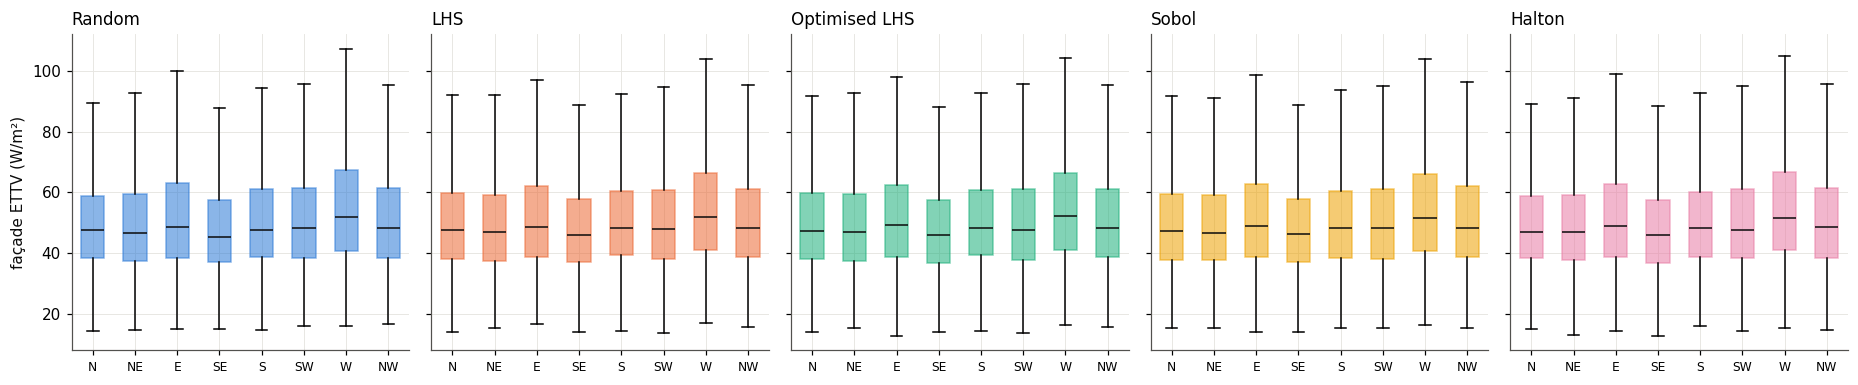

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), sharey=True)
for ax, m in zip(axes, METHODS):
    d = datasets[m]
    long_m = pd.concat([pd.DataFrame({"o": d[f"orient_{i}"], "e": d[f"ettv_{i}"]}) for i in range(1, 5)])
    bp = ax.boxplot([long_m.loc[long_m.o == o, "e"] for o in ORIENTATIONS], tick_labels=ORIENTATIONS,
                    patch_artist=True, showfliers=False, widths=0.55, medianprops=dict(color=INK))
    for b in bp["boxes"]: b.set(facecolor=M_COL[m], alpha=0.55, edgecolor=M_COL[m])
    ax.set_title(m, loc="left", fontsize=11); ax.tick_params(axis="x", labelsize=8)
axes[0].set_ylabel("façade ETTV (W/m²)")
plt.tight_layout(); plt.savefig(FIG / "17_orientation_by_method.png", bbox_inches="tight")

### 14.6 Glazing ratio vs ETTV, coloured by SC1 (as §3.6)

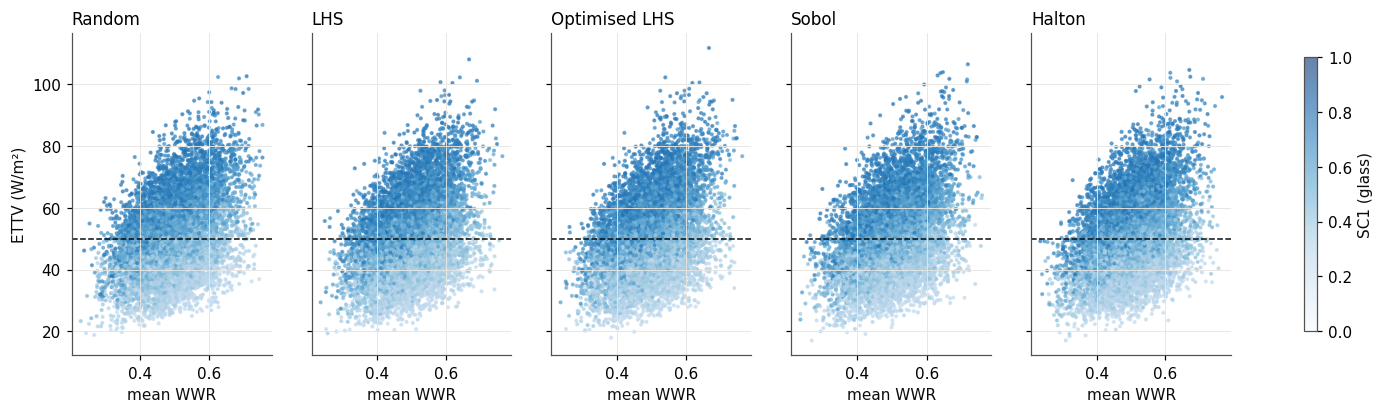

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.8), sharey=True)
for ax, m in zip(axes, METHODS):
    d = datasets[m]; wm = d[["wwr_1", "wwr_2", "wwr_3", "wwr_4"]].mean(axis=1)
    sc = ax.scatter(wm, d.ettv, c=d.sc1, cmap="Blues", s=3, alpha=0.6, vmin=0, vmax=1)
    ax.axhline(ETTV_LIMIT, color=INK, linestyle="--", linewidth=1)
    ax.set_title(m, loc="left", fontsize=11); ax.set_xlabel("mean WWR")
axes[0].set_ylabel("ETTV (W/m²)")
fig.colorbar(sc, ax=axes, shrink=0.85, label="SC1 (glass)")
plt.savefig(FIG / "18_wwr_vs_ettv_by_method.png", bbox_inches="tight")

### 14.7 Rotation (as §3.7)

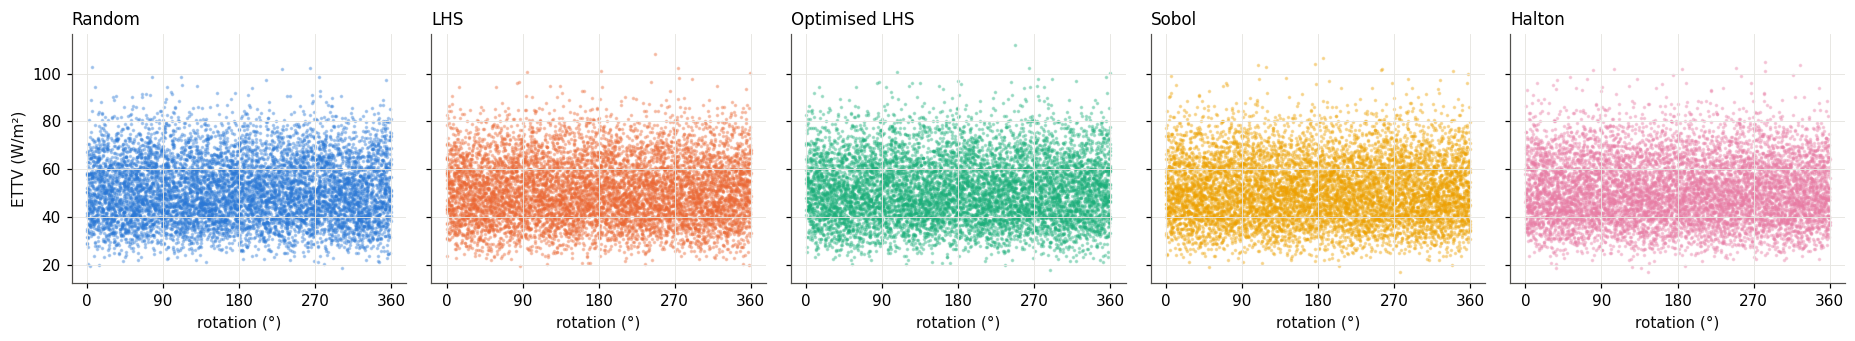

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.2), sharey=True)
for ax, m in zip(axes, METHODS):
    ax.scatter(datasets[m].rotation_deg, datasets[m].ettv, s=2, alpha=0.3, color=M_COL[m])
    ax.set_title(m, loc="left", fontsize=11); ax.set_xticks(range(0, 361, 90)); ax.set_xlabel("rotation (°)")
axes[0].set_ylabel("ETTV (W/m²)")
plt.tight_layout(); plt.savefig(FIG / "19_rotation_by_method.png", bbox_inches="tight")

## 15. Validation: does the sampling method change surrogate accuracy?
**Test set:** 3,000 designs drawn with a *different* seed (plain random, so it favours no method). None of these
designs appear in any training set.

### 15.1 Learning curves (the comparison from the v2 write-up)
Each method trains gradient boosting and the neural net on 128, 512 and 2,048 samples, repeated with 4 seeds.
Points are the mean test MAE, and bars span the best and worst seed. This is the same code as `compare_sampling.py`
and takes about 3 minutes.

done n = 128


done n = 512


done n = 2048


method                  Random   LHS  Optimised LHS  Sobol  Halton
model             n                                               
Gradient boosting 128     4.21  4.18           3.73   4.07    4.00
                  512     3.24  3.15           3.10   3.03    3.17
                  2048    2.24  2.27           2.18   2.36    2.23
Neural net        128     5.14  5.41           4.74   5.16    4.84
                  512     3.80  3.57           3.72   4.06    3.80
                  2048    2.21  2.10           2.17   2.31    2.11

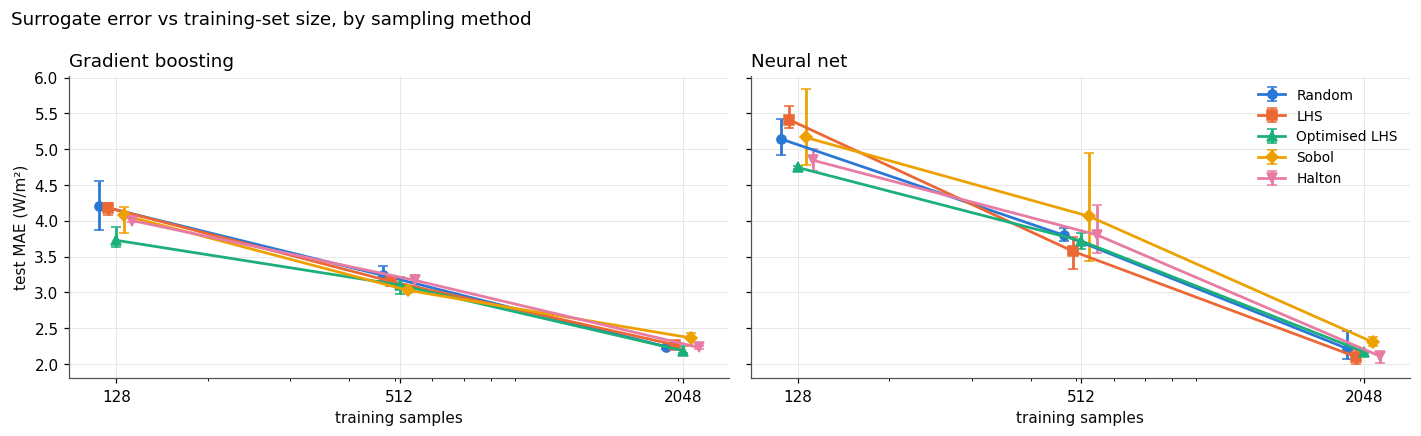

In [37]:
from compare_sampling import run as run_comparison
cmp_df = run_comparison(sizes=(128, 512, 2048), seeds=range(4))
cmp_df.to_csv("data/sampling_comparison.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, mdl in zip(axes, ["Gradient boosting", "Neural net"]):
    sub = cmp_df[cmp_df.model == mdl]
    for k, m in enumerate(METHODS):
        g = sub[sub.method == m].groupby("n").mae
        x = np.array(g.mean().index) * (1 + 0.04 * (k - 2))          # small offset so markers don't hide each other
        ax.errorbar(x, g.mean(), yerr=np.clip([g.mean() - g.min(), g.max() - g.mean()], 0, None), color=M_COL[m], marker=M_MRK[m],
                    markersize=6, linewidth=1.8, capsize=3, label=m)
    ax.set_xscale("log"); ax.set_xticks([128, 512, 2048]); ax.set_xticklabels(["128", "512", "2048"])
    ax.set_xlabel("training samples"); ax.set_title(mdl, loc="left")
axes[0].set_ylabel("test MAE (W/m²)"); axes[1].legend(frameon=False, fontsize=9)
plt.suptitle("Surrogate error vs training-set size, by sampling method", x=0.01, ha="left")
plt.tight_layout(); plt.savefig(FIG / "20_learning_curve_by_method.png", bbox_inches="tight")
tbl = cmp_df.groupby(["model", "n", "method"]).mae.agg(["mean", "std"]).round(2)
tbl["mean"].unstack("method")[METHODS]

In [38]:
# Consistency across seeds: smaller spread = less dependent on a lucky draw
cmp_df.groupby(["model", "n", "method"]).mae.std().unstack("method")[METHODS].round(2)

method                  Random   LHS  Optimised LHS  Sobol  Halton
model             n                                               
Gradient boosting 128     0.29  0.08           0.13   0.17    0.04
                  512     0.10  0.05           0.11   0.05    0.07
                  2048    0.03  0.04           0.05   0.07    0.02
Neural net        128     0.23  0.14           0.01   0.47    0.13
                  512     0.08  0.19           0.09   0.68    0.29
                  2048    0.17  0.08           0.02   0.06    0.06

### 15.2 Full-size validation: parity and residual plots for each method (as §6.1)
Each method's full 8,192-row dataset is split 85/15 into train and validation. The neural net from Part A is retrained
on the training part and scored on the same common test set.

A neural net's result also depends on its random starting weights, so each one is trained **3 times** (3 seeds).
The table shows the mean and the range. The plots show the run with the middle (median) MAE. Without this, one unlucky
initialisation could look like a sampling effect.

In [39]:
from compare_sampling import features as cs_features
test_df, _ = generate_dataset("Random", 3000, 999)
X_test_c, y_test_c = cs_features(test_df), test_df.ettv.values
full_rows, preds, seed_mae, bands_m = {}, {}, {}, {}
for m in METHODS:
    d = datasets[m]; Xm, ym = cs_features(d), d.ettv.values
    Xa, Xv, ya, yv = train_test_split(Xm, ym, test_size=0.15, random_state=SEED)
    runs = []
    for rs in (SEED, 1, 2):                                   # 3 random initialisations
        mdl = clone(models["Neural net (MLP)"]).set_params(mlpregressor__random_state=rs).fit(Xa, ya)
        p = mdl.predict(X_test_c); runs.append((mean_absolute_error(y_test_c, p), p, mdl))
    runs.sort(key=lambda t: t[0])
    seed_mae[m] = [r[0] for r in runs]
    preds[m] = runs[1][1]                                     # median run for the plots
    bands_m[m] = float(np.percentile(np.abs(runs[1][2].predict(Xv) - yv), 95))   # calibrated on held-out 15%
    full_rows[m] = score(y_test_c, preds[m])
full_val = pd.DataFrame({m: {"MAE mean (3 seeds)": np.mean(v), "MAE min": min(v), "MAE max": max(v),
                             "R2 (median run)": full_rows[m]["R2"], "pass/fail acc (median run)": full_rows[m]["pass/fail acc"],
                             **{k: v for k, v in band_report(y_test_c, preds[m], bands_m[m]).items() if k != "MAE"}}
                         for m, v in seed_mae.items()}).T
full_val.round(3)

,MAE mean (3 seeds),MAE min,MAE max,R2 (median run),pass/fail acc (median run),band ±(W/m²),coverage (|err| ≤ band),flipped,flipped & caught,silent flips,share flagged borderline
Random,1.220,1.188,1.276,0.986,0.967,3.007,0.943,99.0,95.0,4.0,0.162
LHS,1.233,1.204,1.291,0.986,0.968,3.023,0.945,96.0,94.0,2.0,0.164
Optimised LHS,1.364,1.186,1.656,0.985,0.971,3.185,0.950,88.0,85.0,3.0,0.172
Sobol,1.299,1.276,1.332,0.984,0.967,3.378,0.951,99.0,98.0,1.0,0.190
Halton,1.396,1.208,1.638,0.983,0.965,3.349,0.946,104.0,99.0,5.0,0.177


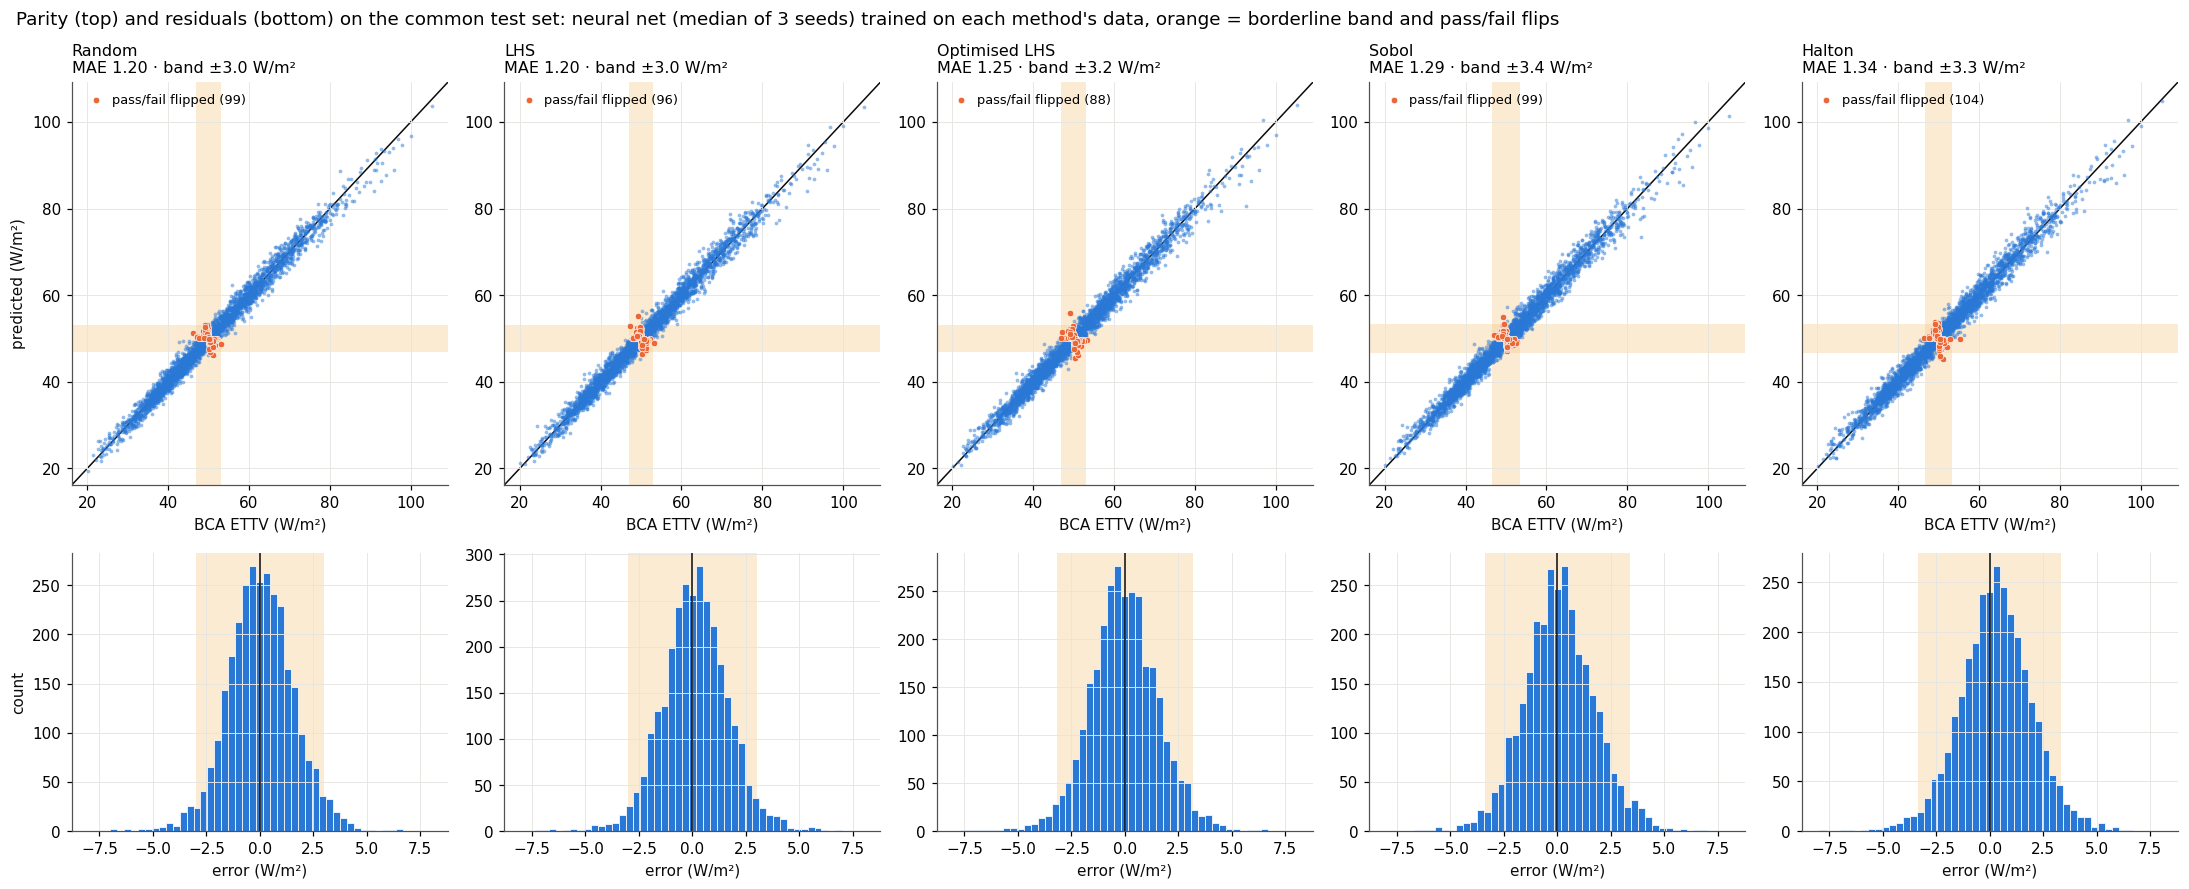

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8.2), gridspec_kw={"height_ratios": [1.45, 1]})
lim = [y_test_c.min() - 4, y_test_c.max() + 4]
for j, m in enumerate(METHODS):
    p = preds[m]
    parity_ax(axes[0, j], y_test_c, p, bands_m[m], f"{m}\nMAE {full_rows[m]['MAE']:.2f} · band ±{bands_m[m]:.1f} W/m²", lim=lim)
    if j == 0: axes[0, j].set_ylabel("predicted (W/m²)")
    ax2 = axes[1, j]
    ax2.axvspan(-bands_m[m], bands_m[m], color=BAND_C, alpha=0.35, lw=0)
    ax2.hist(p - y_test_c, bins=np.linspace(-8, 8, 50), color=BLUE, edgecolor="white", linewidth=0.5)
    ax2.axvline(0, color=INK, linewidth=1); ax2.set_xlabel("error (W/m²)")
    if j == 0: ax2.set_ylabel("count")
plt.suptitle("Parity (top) and residuals (bottom) on the common test set: neural net (median of 3 seeds) trained on each "
             "method's data, orange = borderline band and pass/fail flips", x=0.01, ha="left")
plt.tight_layout(); plt.savefig(FIG / "21_parity_by_method.png", bbox_inches="tight")

## 16. Conclusions from Part B
Numbers are from this run, with fixed seeds, so they reproduce on the same software versions.

**Verification: the sampling plans (§13)**
* **LHS, Optimised LHS and Sobol leave no empty slices.** Random leaves about 37% of each input's slices empty,
  and Halton about 24% at this size.
* **Discrepancy ranks the methods** Sobol (0.0015) < Halton (0.0016) < Optimised LHS (0.0024) < LHS (0.0037) < Random (0.0047).
* **"Optimised" depends on the criterion.** Optimised LHS minimises discrepancy, not the gap between points, so its
  minimum nearest-neighbour distance is actually the *lowest* of the five. Say which criterion you used when you
  report it.

**Verification: the generated data (§12, §14)**
* **All five datasets tell the same physical story.** Mean ETTV is 51.1–51.2 W/m², 50.1–50.4% of designs pass, and the
  KS statistic against LHS is at most 0.011. Component shares agree within 0.1 percentage points, and every Spearman
  correlation is within 0.024 of LHS. The orientation, WWR × SC1 and rotation graphs look the same.
* So the **EDA conclusions in Part A don't depend on choosing LHS**, which is a useful robustness statement for your paper.

**Validation: the surrogates (§15)**
* **Sampling matters most with few samples.** At 128 samples, gradient boosting on Optimised LHS data had about 11% lower
  error than on Random (3.73 vs 4.21 W/m²), and was more consistent across seeds.
* **With plenty of data the methods converge.** At 2,048 samples they are within about 0.2 W/m² of each other. At 8,192
  the differences between methods are no bigger than the seed-to-seed variation of the neural net itself.

**Recommendation**
* **Interim:** LHS is a sound, standard choice, and Part B shows the results are robust to it.
* **Final:** when each sample is a slow SC2 calculation and only a few hundred are affordable, use **Optimised LHS or
  Sobol** (with *n* a power of 2), and consider adaptive sampling near the 50 W/m² limit.